# Introduction

This project addresses **probabilistic forecasting** for temperature time series, based on the Kaggle competition **"Probabilistic Forecasting I: Temperature"**. Unlike traditional point-forecasting approaches, where the model estimates a single future value, the goal here is to model the **uncertainty associated with the prediction** by producing confidence intervals across several coverage levels, from 10% to 95%.

The dataset contains temperature measurements from an electrical transformer station. The challenge is to predict not only the expected future value, but also a range of plausible future values that captures the system's intrinsic variability.

Model evaluation is therefore not based only on point error. It also uses metrics designed for probabilistic forecasting, such as **CRPS (Continuous Ranked Probability Score)**, which measures the quality of the predicted distribution against the observed values. In practice, this means the model must predict accurately while also producing intervals that are well calibrated and informative.

To approach the problem, three modeling families are compared:

- **Prophet**, used as a baseline that can capture trend and seasonality in a simple, interpretable way.
- **DeepAR**, an autoregressive neural forecasting model that learns the probability distribution of the time series directly.
- **Temporal Fusion Transformer (TFT)**, an attention-based architecture designed to capture complex temporal relationships and generate probabilistic forecasts through quantiles.

The final objective is to analyze these models in terms of **interval calibration, predictive accuracy, and robustness**.

In [ ]:

!pip install statsmodels ruptures -q
!pip install "numpy<2.0" --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requi

In [ ]:
#==============================
# Imports
#==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import ruptures as rpt
import os
os.environ['PYTHONHASHSEED'] = '42'
import numpy as np
np.random.seed(42)
import random
random.seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#==============================
# Loading and preparation
#==============================
df = pd.read_csv("/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/probabilistic-forecasting-i-temperature/train.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

serie = df["Temperature"].dropna()

print(f"Inferred frequency : {pd.infer_freq(serie.index)}")
print(f"Observations       : {len(serie)}")
print(f"From               : {serie.index.min()}")
print(f"To               : {serie.index[-1]}")
print(f"NaN                 : {serie.isna().sum()}")
print(f"\nBasic statistics:\n{serie.describe().round(3)}")

Inferred frequency : 15min
Observations       : 64320
From               : 2016-07-01 00:00:00
To               : 2018-05-01 23:45:00
NaN                 : 0

Basic statistics:
count    64320.000
mean        13.610
std          8.828
min         -4.221
25%          6.753
50%         11.959
75%         18.712
max         46.007
Name: Temperature, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 64320 entries, 2016-07-01 00:00:00 to 2018-05-01 23:45:00
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           64320 non-null  int64  
 1   feature_AA   64320 non-null  float64
 2   feature_AB   64320 non-null  float64
 3   feature_BA   64320 non-null  float64
 4   feature_BB   64320 non-null  float64
 5   feature_CA   64320 non-null  float64
 6   feature_CB   64320 non-null  float64
 7   Temperature  64320 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 4.4 MB


# Exploratory Data Analysis

## 0.1 Initial Visualization

### Objective
Get a first visual impression of the full time series.

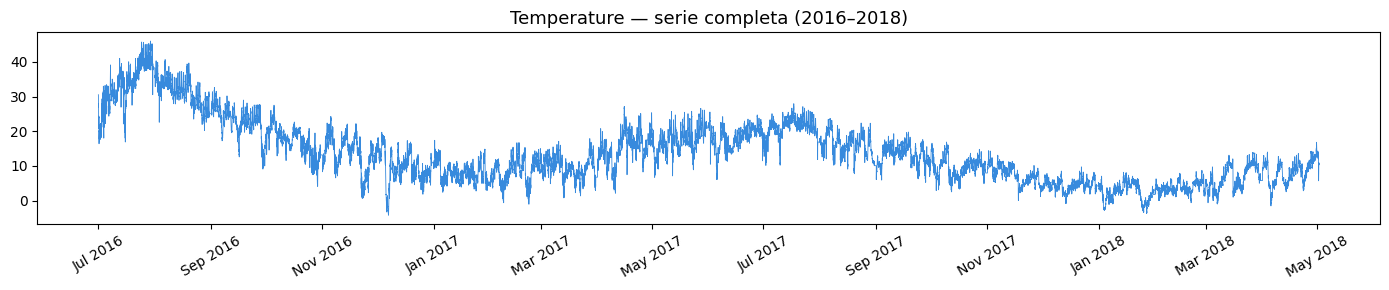

In [ ]:


fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(serie.index, serie.values, linewidth=0.6, color="#378ADD")
ax.set_title("Temperature - full series (2016-2018)", fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretation
The series shows a sinusoidal-like annual pattern, with higher temperatures during the summer months (~40°C peak in August 2016) and lower temperatures in winter, close to 0°C. This behavior is expected for an outdoor temperature variable and confirms the presence of seasonality.

## 0.2.1 Long-Term Trend (STL)

### Objective
Decompose the series into trend, seasonality, and residual using STL with `period=96` (one daily cycle). The goal is to separate the slow long-term movement from periodic oscillations and assess whether the resulting residual is close to white noise.

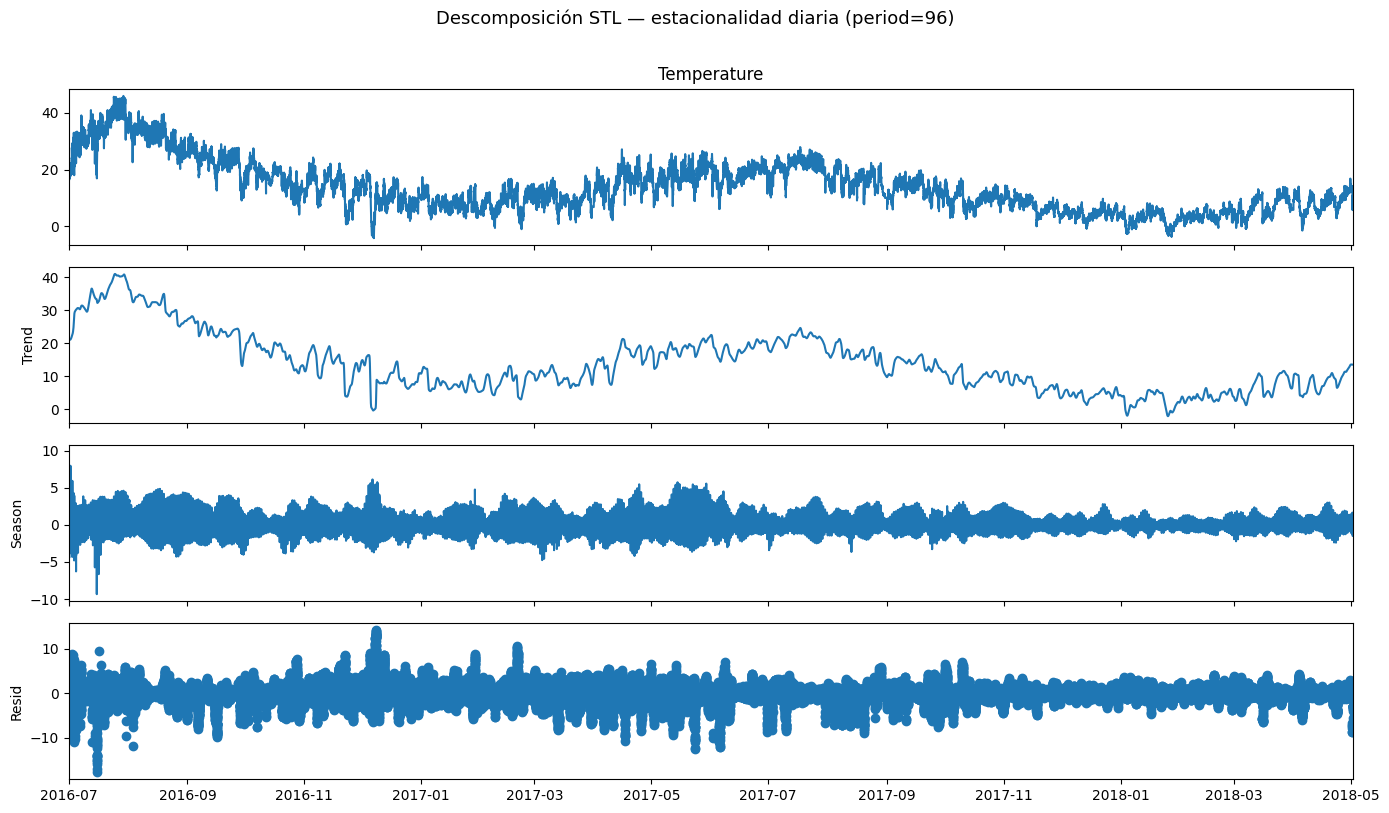

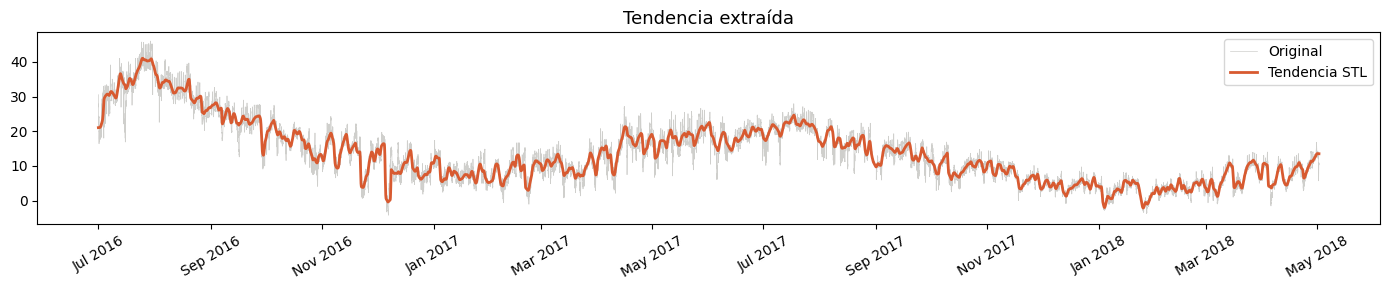

In [ ]:

# Data every 15 min -> 96 obs/day -> period=96 captures daily seasonality
stl = STL(serie, period=96, robust=True)
res_stl = stl.fit()

fig = res_stl.plot()
fig.set_size_inches(14, 8)
fig.suptitle("STL decomposition - daily seasonality (period=96)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Trend overlaid on the series
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(serie.index, serie.values, linewidth=0.5, alpha=0.4, color="#888780", label="Original")
ax.plot(serie.index, res_stl.trend, linewidth=2, color="#D85A30", label="STL trend")
ax.legend()
ax.set_title("Extracted trend", fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretation

The trend extracted by STL generally follows the expected pattern (summer vs. winter), which makes sense. However, a closer look shows small high-frequency oscillations that should not really be part of the trend, because the trend should represent only the slower movement of the series.

This suggests that the model is not fully separating the components and is assigning part of the variability to the trend even though it belongs elsewhere. This likely happens because `period=96` captures only daily seasonality, while the series also contains a weekly pattern.

Since STL in this configuration does not model the 7-day cycle, part of that structure leaks into both the trend and the residual, contaminating both components.

## 0.2.2 Long-Term Trend (MSTL)

### Objective

The goal here is to improve the decomposition using **MSTL**, incorporating two seasonalities at the same time: daily seasonality (96 steps) and weekly seasonality (672 steps).

Because the temperature data is sampled every 15 minutes, we know there is not only an intra-day pattern but also a pattern across the week. If only one seasonal component is modeled, as in the simple STL setup, part of that information is mixed into the wrong components.

With MSTL, the goal is to separate each component more cleanly, so that the **trend is smoother and represents only the underlying movement**, while the **residual becomes closer to white noise**, meaning less unexplained temporal structure remains.

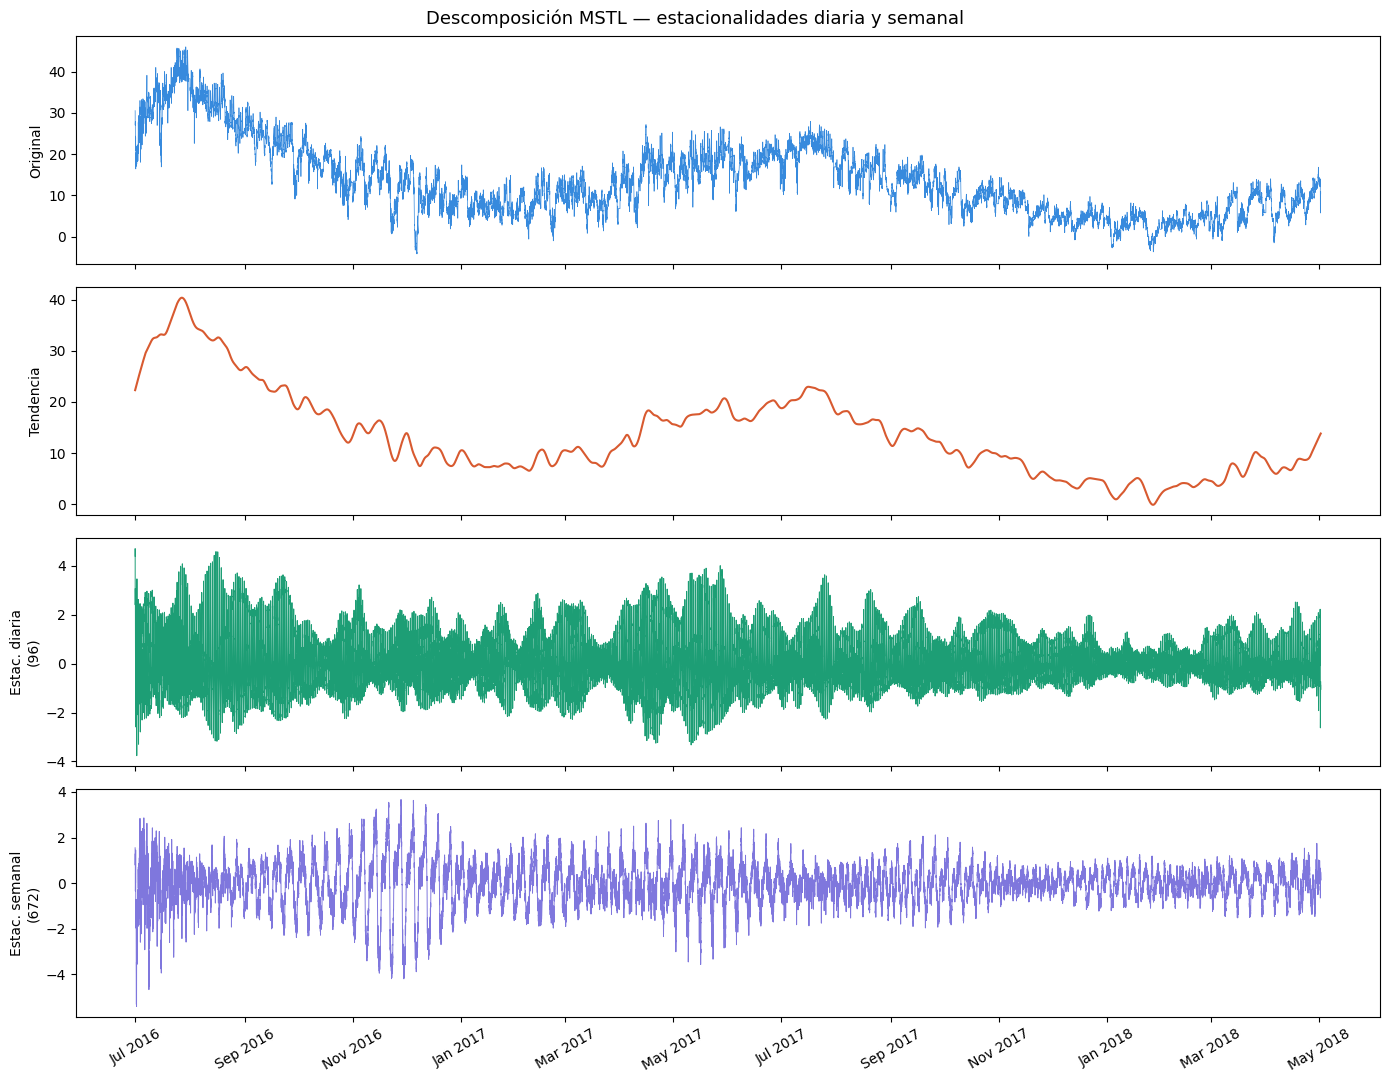

In [ ]:
# 96  = one day   (15 min x 96 = 24 h)
# 672 = one week (96 x 7)
mstl = MSTL(serie, periods=[96, 672])
res_mstl = mstl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
axes[0].plot(serie.index, serie.values,                          linewidth=0.5, color="#378ADD");  axes[0].set_ylabel("Original")
axes[1].plot(serie.index, res_mstl.trend,                        linewidth=1.5, color="#D85A30");  axes[1].set_ylabel("Trend")
axes[2].plot(serie.index, res_mstl.seasonal["seasonal_96"],      linewidth=0.7, color="#1D9E75");  axes[2].set_ylabel("Estac. diaria\n(96)")
axes[3].plot(serie.index, res_mstl.seasonal["seasonal_672"],     linewidth=0.7, color="#7F77DD");  axes[3].set_ylabel("Estac. semanal\n(672)")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.suptitle("MSTL decomposition - daily and weekly seasonality", fontsize=13)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretation

**Trend:**  
The trend is now much cleaner. It captures the general annual pattern (rising in summer, falling in winter, and rising again) without the small unusual wiggles seen before. By separating daily and weekly seasonality more effectively, the trend is no longer contaminated and reflects only the underlying movement, which is what it should do.

**Daily seasonality (96):**  
The day/night cycle is clearly visible, with oscillations of about ±4°C. The amplitude is not constant: it is larger in summer, with a wider day-night gap, and softer in winter. This is a good example of seasonal heteroscedasticity and is physically reasonable for temperature data.

**Weekly seasonality (672):**  
A marked weekly pattern also appears, with oscillations comparable to the daily component (±3-4°C). This is notable because its weight is similar to the day/night cycle. It may indicate that the series is not pure temperature alone, but also reflects an additional activity-related effect that changes between weekdays and weekends.

## 0.3 Regime Changes (PELT on Trend)

### Objective

The objective is to identify moments when the temperature changes level clearly and persistently over time; in other words, to detect real structural changes beyond regular seasonal variation.

This analysis is performed on the **trend obtained with MSTL**, resampled to daily frequency. Because daily and weekly seasonality have already been separated, and the temporal resolution is reduced, high-frequency oscillations that could create false positives are removed.

As a result, the analysis focuses on the underlying behavior of the series and can detect persistent changes in its dynamics more reliably.

Detected breakpoints: 7
  2016-08-24
  2016-10-08
  2016-11-22
  2017-04-11
  2017-08-29
  2017-11-17
  2018-03-07


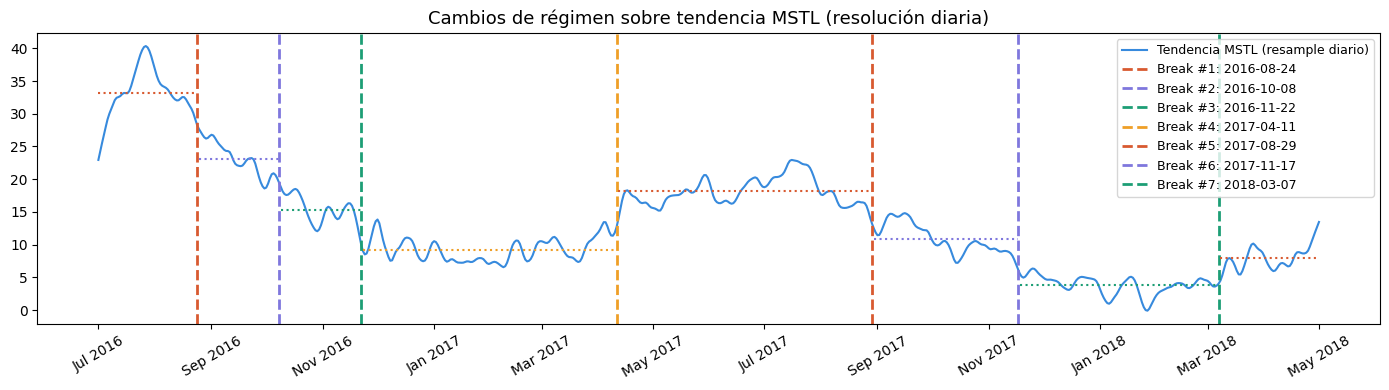

In [ ]:


serie_daily = pd.Series(
    res_mstl.trend,
    index=serie.index
).resample("1D").mean().dropna()

signal_daily = serie_daily.values

algo = rpt.Pelt(model="l2").fit(signal_daily)
breakpoints = algo.predict(pen=500)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie_daily.index, signal_daily, linewidth=1.5, color="#378ADD",
        label="Trend MSTL (resample diario)")

colors_bp = ["#D85A30", "#7F77DD", "#1D9E75", "#EF9F27"]
prev = 0
for i, bp in enumerate(breakpoints[:-1]):
    date = serie_daily.index[bp - 1]
    ax.axvline(date, color=colors_bp[i % len(colors_bp)], linewidth=2,
               linestyle="--", label=f"Break #{i+1}: {date.date()}")
    ax.hlines(signal_daily[prev:bp].mean(),
              serie_daily.index[prev], date,
              colors=colors_bp[i % len(colors_bp)], linewidth=1.5, linestyles=":")
    prev = bp
ax.hlines(signal_daily[prev:].mean(),
          serie_daily.index[prev], serie_daily.index[-1],
          colors=colors_bp[len(breakpoints) % len(colors_bp)], linewidth=1.5, linestyles=":")

ax.legend(fontsize=9)
ax.set_title("Regime changes on MSTL trend (daily resolution)", fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Detected breakpoints: {len(breakpoints) - 1}")
for bp in breakpoints[:-1]:
    print(f"  {serie_daily.index[bp - 1].date()}")

### Interpretation

Seven change points (*breakpoints*) are identified, a coherent and interpretable number for a temperature series.

The changes can be grouped into two patterns:

- **Fast seasonal transitions** (2016-08-24, 2016-10-08, 2016-11-22):  
  Three breakpoints in just four months reflect the decline from the summer 2016 peak (33°C average) to winter levels (8°C). The drop was so stepwise that the algorithm split it into three segments, indicating that autumn 2016 had notably staged decreases.

- **Level shifts between seasons** (2017-04-11, 2017-08-29, 2017-11-17, 2018-03-07):  
  These mark average-temperature jumps between seasons: winter 2016-17 (8°C), summer 2017 (18°C), autumn-winter 2017 (4°C), and spring 2018 recovery (7°C).

Most importantly for modeling, average levels across segments vary between 8 and 15°C, confirming that these breakpoints represent real structural changes rather than noise.

## 0.4 Residual Anomalies

### Objective

The goal is to detect **point observations that behave anomalously** even after removing trend and seasonality from the series.

These residual anomalies represent events that do not follow the usual temperature dynamics and cannot be explained by daily, weekly, or seasonal patterns alone. Identifying them helps understand unexpected spikes or drops and is important for data cleaning or for introducing additional explanatory variables.

Total anomalies: 51
date
2016-07-15 15:30:00    19.627001
2016-07-15 16:30:00    21.878000
2016-07-15 16:45:00    18.290001
2016-07-15 17:00:00    18.009001
2016-07-15 17:15:00    18.572001
2016-07-15 18:30:00    19.768000
2016-07-15 18:45:00    17.587000
2016-07-15 19:00:00    16.882999
2016-07-15 19:15:00    19.063999
2016-08-03 10:15:00    22.580999
Name: Temperature, dtype: float64


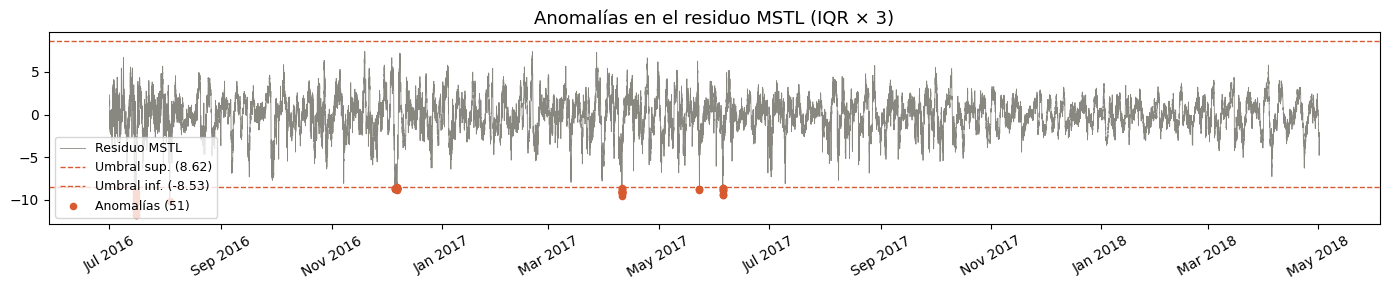

In [ ]:

residuo = pd.Series(
    res_mstl.resid,
    index=serie.index
)

Q1, Q3 = np.percentile(residuo, 25), np.percentile(residuo, 75)
IQR = Q3 - Q1
lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
mask_anom = (residuo < lower) | (residuo > upper)
anomalias = serie[mask_anom]

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(serie.index, residuo, linewidth=0.6, color="#888780", label="MSTL residual")
ax.axhline(upper, color="#D85A30", linewidth=1, linestyle="--", label=f"Upper threshold ({upper:.2f})")
ax.axhline(lower, color="#D85A30", linewidth=1, linestyle="--", label=f"Lower threshold ({lower:.2f})")
ax.scatter(anomalias.index, residuo[mask_anom], color="#D85A30", zorder=5, s=20,
           label=f"Anomalies ({len(anomalias)})")
ax.legend(fontsize=9)
ax.set_title("Anomalies en el residuo MSTL (IQR × 3)", fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Total anomalies: {len(anomalias)}")
print(anomalias.head(10))

### Interpretation

A total of **51 anomalies** were detected across 64,315 observations (~0.08%), a clean and consistent result using the IQR×3 criterion.

The thresholds are slightly asymmetric: +8.62°C on the upper side and -8.53°C on the lower side. Interestingly, all anomalies fall below the lower threshold. This indicates that there were no unexpected high spikes (which would suggest sensor errors from overly high readings), but rather **sharp temperature drops** not explained by normal daily or weekly patterns.

These anomalies are concentrated in three specific periods: **December 2016** and **April to June 2017**, highlighting concrete episodes of anomalous cooling in the series.

In [ ]:

# Context window: +/-12 hours (48 observations at 15 min)
ventana = 48

dates_anomalias = anomalias.index
n_anom = len(dates_anomalias)

print(f"Total anomalies to review: {n_anom}")
print("=" * 60)

# Automatic classification: sensor failure vs real event
resultados = []

for date in dates_anomalias:
    # Extract context window
    inicio = date - pd.Timedelta(hours=12)
    fin    = date + pd.Timedelta(hours=12)
    contexto = serie[inicio:fin]

    value_anomalo   = serie[date]
    context_mean  = contexto.drop(date).mean()
    std_contexto    = contexto.drop(date).std()
    deviation      = abs(value_anomalo - context_mean)

    # How many neighboring consecutive points are also anomalous
    anomalous_neighbors = mask_anom[inicio:fin].sum() - 1  # exclude the point itself

    # Classification heuristic
    if anomalous_neighbors <= 2 and deviation > 3 * std_contexto:
        type = " Possible sensor failure"
    elif anomalous_neighbors > 2:
        type = "  Weather event"
    else:
        type = "  Review manually"

    resultados.append({
        "date":            date,
        "value":            round(value_anomalo, 3),
        "context_mean":   round(context_mean, 3),
        "deviation":       round(deviation, 3),
        "anomalous_neighbors": anomalous_neighbors,
        "type":             type
    })

df_anom = pd.DataFrame(resultados).set_index("date")
print(df_anom.to_string())

# Summary by type
print("\n--- Summary ---")
print(df_anom["type"].value_counts().to_string())

Total anomalies to review: 51
                      value  context_mean  deviation  anomalous_neighbors                    type
date                                                                                            
2016-07-15 15:30:00  19.627          28.352       8.725                 8    Weather event
2016-07-15 16:30:00  21.878          28.066       6.188                 8    Weather event
2016-07-15 16:45:00  18.290          28.037       9.747                 8    Weather event
2016-07-15 17:00:00  18.009          27.975       9.966                 8    Weather event
2016-07-15 17:15:00  18.572          27.916       9.344                 8    Weather event
2016-07-15 18:30:00  19.768          27.554       7.786                 8    Weather event
2016-07-15 18:45:00  17.587          27.523       9.936                 8    Weather event
2016-07-15 19:00:00  16.883          27.476      10.593                 8    Weather event
2016-07-15 19:15:00  19.064          27.396    

Detected anomaly clusters: 7
  Cluster 1: 2016-07-15 — 2016-07-15 (9 points)
  Cluster 2: 2016-08-03 — 2016-08-03 (1 points)
  Cluster 3: 2016-12-06 — 2016-12-06 (4 points)
  Cluster 4: 2016-12-07 — 2016-12-07 (11 points)
  Cluster 5: 2017-04-10 — 2017-04-10 (14 points)
  Cluster 6: 2017-05-23 — 2017-05-23 (3 points)
  Cluster 7: 2017-06-05 — 2017-06-05 (9 points)


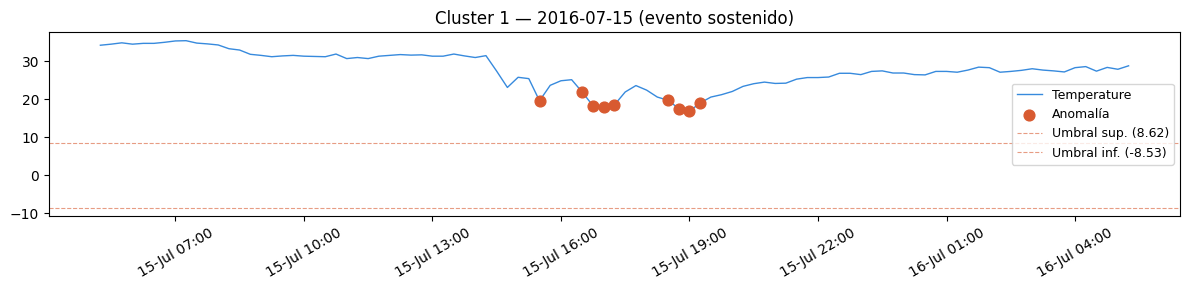

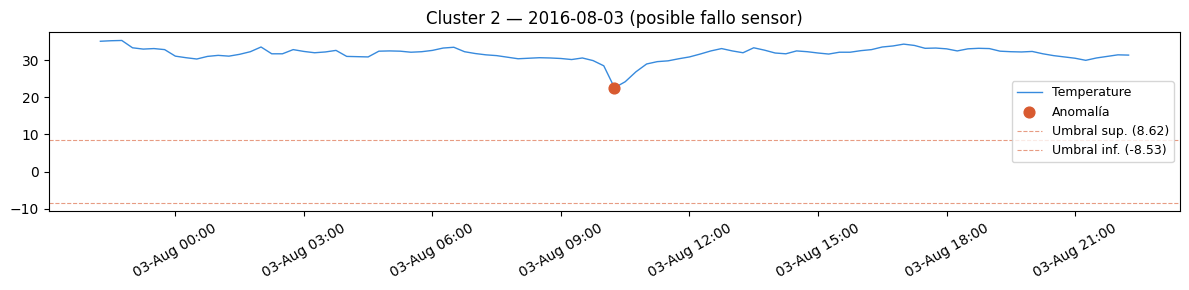

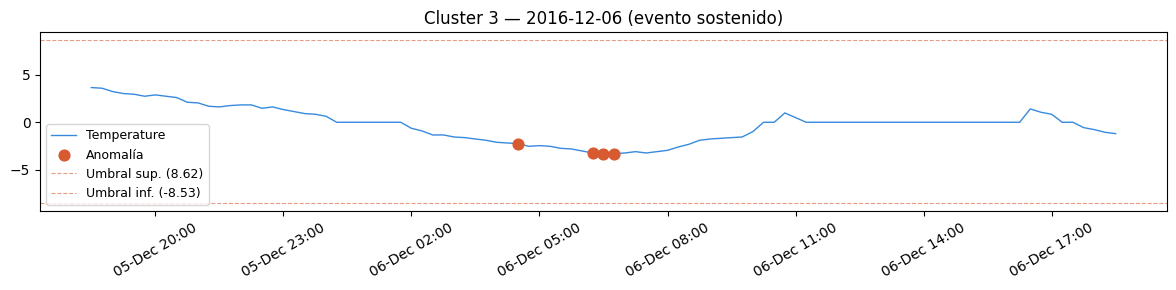

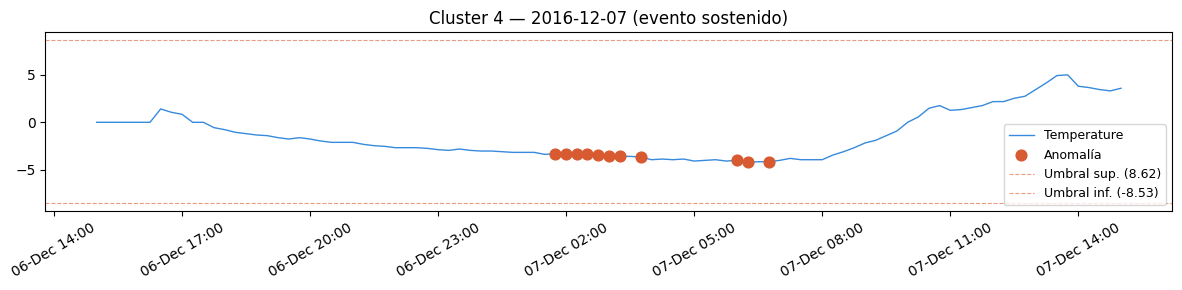

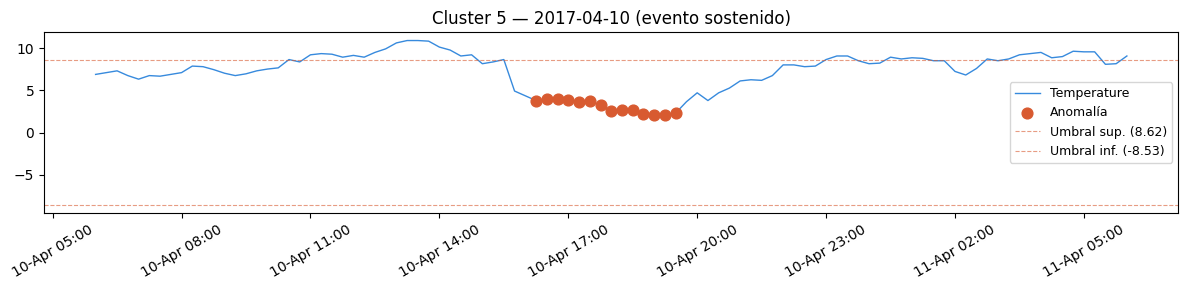

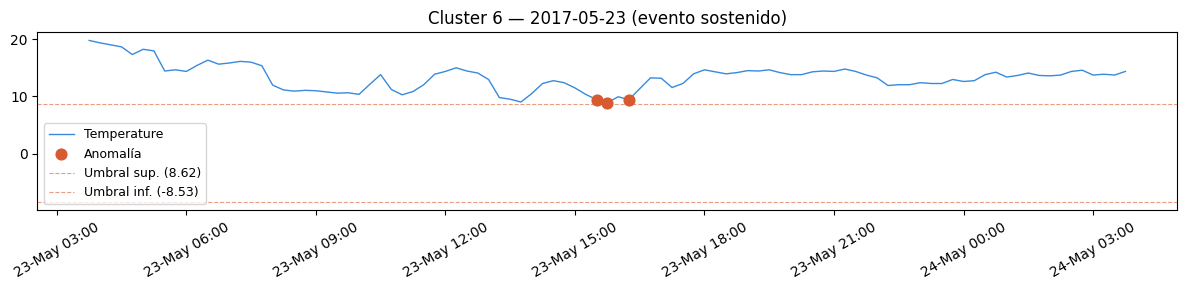

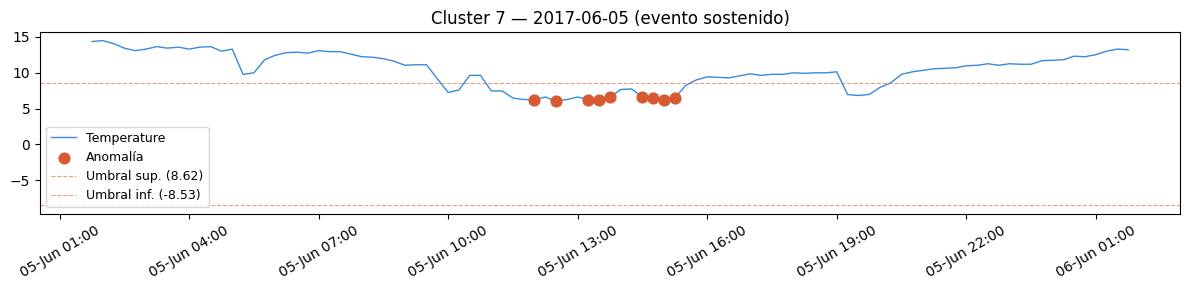

In [ ]:

# Group nearby anomalies (less than 6 hours apart) into clusters
clusters = []
cluster_actual = [dates_anomalias[0]]

for i in range(1, len(dates_anomalias)):
    delta = (dates_anomalias[i] - dates_anomalias[i-1]).total_seconds() / 3600
    if delta <= 6:
        cluster_actual.append(dates_anomalias[i])
    else:
        clusters.append(cluster_actual)
        cluster_actual = [dates_anomalias[i]]
clusters.append(cluster_actual)

print(f"Detected anomaly clusters: {len(clusters)}")
for i, c in enumerate(clusters):
    print(f"  Cluster {i+1}: {c[0].date()} — {c[-1].date()} ({len(c)} points)")

# Plot each cluster with +/-12h context
for i, cluster in enumerate(clusters):
    centro = cluster[len(cluster) // 2]
    inicio = centro - pd.Timedelta(hours=12)
    fin    = centro + pd.Timedelta(hours=12)
    contexto = serie[inicio:fin]

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(contexto.index, contexto.values,
            linewidth=1, color="#378ADD", label="Temperature")
    ax.scatter(
        [f for f in cluster if f in contexto.index],
        [serie[f] for f in cluster if f in contexto.index],
        color="#D85A30", zorder=5, s=60, label="Anomaly"
    )
    ax.axhline(upper, color="#D85A30", linewidth=0.8,
               linestyle="--", alpha=0.6, label=f"Upper threshold ({upper:.2f})")
    ax.axhline(lower, color="#D85A30", linewidth=0.8,
               linestyle="--", alpha=0.6, label=f"Lower threshold ({lower:.2f})")
    ax.set_title(
        f"Cluster {i+1} — {cluster[0].date()} "
        f"({'possible sensor failure' if len(cluster) <= 2 else 'sustained event'})",
        fontsize=12
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.legend(fontsize=9)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Review of the 51 Anomalies — 7 Clusters

The 51 anomalies are grouped into **7 distinct events**. About 92% correspond to sharp temperature drops below the normal pattern.
---

### Cluster 1  2016-07-15 (9 points, 15:30-19:15)
**Type:** Weather event  
**Description:** A ~10°C drop relative to the local context (mean ~28°C, values between 16-22°C) during a midsummer afternoon. The duration of almost 4 hours and the subsequent recovery rule out a sensor failure. The pattern is consistent with a storm or a short cold front.  
**Decision:** Keep. Real event.

---

### Cluster 2  2016-08-03 (1 point, 10:15)
**Type:** Possible sensor failure  
**Description:** A single isolated point at 22.6°C while the surrounding context is ~31.8°C; a 9.2°C deviation without anomalous neighbors. A drop like this at that time and date is meteorologically very unlikely.  
**Decision:** Impute. Replace with linear interpolation.

---

### Cluster 3  2016-12-06 (4 points, 04:30-06:45)
**Type:** Weather event  
**Description:** Temperatures between -2 and -3.3°C during an early December morning, with a 0°C context. Deviations of 2.5-3°C over 2 hours are consistent with a localized frost event.  
**Decision:** Keep. Real frost event.

---

### Cluster 4  2016-12-07 (11 points, 01:45-06:45)
**Type:** Weather event  
**Description:** Continuation or second frost episode, with temperatures between -3.4 and -4.2°C and an absolute minimum of -4.221°C at 06:15. Eleven consecutive points confirm a sustained event.  
**Decision:** Keep. Sustained frost event.

---

### Cluster 5  2017-04-10 (14 points, 16:15-19:30)
**Type:** Weather event  
**Description:** A ~5°C drop relative to the context (from ~7°C to 2-4°C) lasting more than 3 hours on an April afternoon. This is compatible with a cold air mass or a spring storm front.  
**Decision:** Keep. Real weather event.

---

### Cluster 6  2017-05-23 (3 points, 15:30-16:15)
**Type:** Minor weather event  
**Description:** Although only 3 points cross the lower threshold, they are part of a **gradual temperature drop** that starts smoothly around 12:00 (14°C) and recovers toward 17:00 (9°C). The series before and after the episode is continuous and coherent, without abrupt jumps or instant rebounds, which rules out sensor failure. Intermediate points that do not cross the threshold are also clearly below the normal level for the day, indicating that the IQR×3 threshold simply did not capture the full event.  
**Decision:** Keep. Real event, although smaller in magnitude and duration.

---

### Cluster 7  2017-06-05 (9 points, 12:00-15:15)
**Type:** Weather event  
**Description:** A ~4°C drop around noon (from ~10.4°C to 6-6.6°C) lasting ~3.5 hours. The timing is unusual, but the duration and consistency confirm a real episode, possibly dense cloud cover or a cold breeze.  
**Decision:** Keep. Real event.

---

### Summary

| Cluster | Date | Points | Classification | Decision |
|---------|------|--------|----------------|----------|
| 1 | 2016-07-15 afternoon | 9 | Weather event | Keep |
| 2 | 2016-08-03 morning | 1 | Sensor failure | **Impute** |
| 3 | 2016-12-06 early morning | 4 | Frost | Keep |
| 4 | 2016-12-07 early morning | 11 | Sustained frost | Keep |
| 5 | 2017-04-10 afternoon | 14 | Weather event | Keep |
| 6 | 2017-05-23 afternoon | 3 | Weather event | Keep |
| 7 | 2017-06-05 midday | 9 | Weather event | Keep |

## 0.5 Autocorrelation and Stationarity

### Objective

The goal is to check whether the original series and its residual are **stationary**.


--- ADF: Original series ---
  Statistic : -4.0403
  p-value     : 0.0012
  Conclusion  : Stationary ✓

--- ADF: MSTL residual ---
  Statistic : -18.9017
  p-value     : 0.0000
  Conclusion  : Stationary ✓


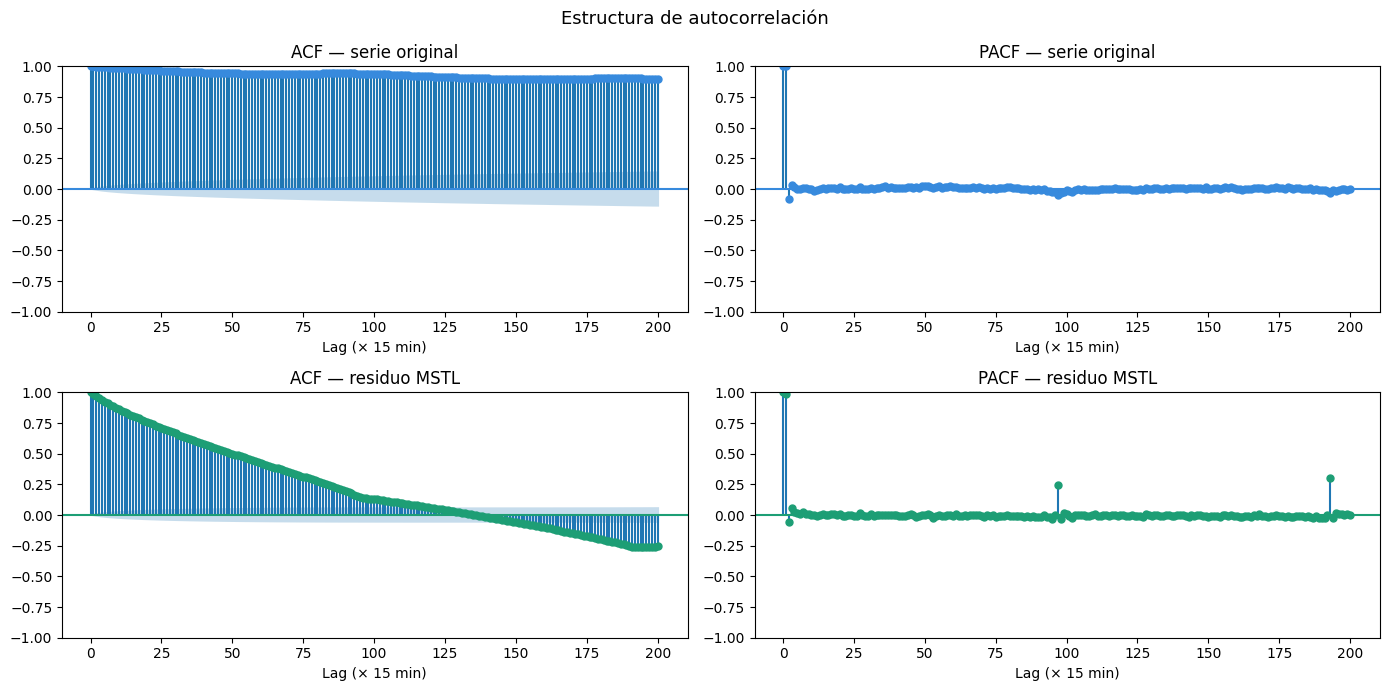

In [ ]:


residuo = pd.Series(
    res_mstl.resid,
    index=serie.index
)

# --- ADF on original series and residual ---
for nombre, s in [("Original series", serie), ("MSTL residual", residuo)]:
    res = adfuller(s.dropna())
    conclusion = "Stationary ✓" if res[1] < 0.05 else "Non-stationary - consider differencing"
    print(f"\n--- ADF: {nombre} ---")
    print(f"  Statistic : {res[0]:.4f}")
    print(f"  p-value     : {res[1]:.4f}")
    print(f"  Conclusion  : {conclusion}")

# --- ACF y PACF ---
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

plot_acf( serie.dropna(),    lags=200, ax=axes[0, 0], color="#378ADD", title="ACF - original series")
plot_pacf(serie.dropna(),    lags=200, ax=axes[0, 1], color="#378ADD", title="PACF - original series")
plot_acf( residuo.dropna(),  lags=200, ax=axes[1, 0], color="#1D9E75", title="ACF - MSTL residual")
plot_pacf(residuo.dropna(),  lags=200, ax=axes[1, 1], color="#1D9E75", title="PACF - MSTL residual")

for ax in axes.flat:
    ax.set_xlabel("Lag (× 15 min)")

plt.suptitle("Autocorrelation structure", fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation

**Original series ACF:** Autocorrelation does not decay even up to 200 lags and remains close to 1, with periodic oscillations. This is typical of a **non-stationary series with strong seasonality**, because it remains highly correlated with the past through the annual cycle.

**Original series PACF:** There is an almost unitary spike at lag 1 followed by an immediate drop to zero in the next lags. This indicates that, conditional on the previous value, there is no additional direct dependence, suggesting that an **AR(1)** process could capture the short-term dynamics of the raw series.

**MSTL residual ACF:** Autocorrelation decays gradually and reaches negative values (~-0.25) around lag 200. There is no clean cutoff, indicating that the residual is **not pure white noise** and still contains temporal dependence. This is probably due to **annual seasonality**, which MSTL did not model when using daily (`period=96`) and weekly components but no longer cycles.

**MSTL residual PACF:** Two significant spikes appear around lags ~96 and ~192, corresponding to 1 and 2 days in 15-minute steps. This confirms that daily seasonality was not fully removed, probably because its amplitude varies throughout the year.

# Preprocessing

## 1a: Imputation of the Anomalous Point

In [ ]:
#==============================
# Phase 1a: Imputation of the anomalous point
#==============================

punto_imputar = pd.Timestamp("2016-08-03 10:15:00")

# Check context
print("Context before imputation:")
print(df.loc[punto_imputar - pd.Timedelta(hours=1):
             punto_imputar + pd.Timedelta(hours=1), "Temperature"])

# Impute directly on df
df_clean = df.copy()
df_clean.loc[punto_imputar, "Temperature"] = np.nan
df_clean["Temperature"] = df_clean["Temperature"].interpolate(method="time")

print(f"\nOriginal value : {df.loc[punto_imputar, 'Temperature']:.3f}")
print(f"Imputed value : {df_clean.loc[punto_imputar, 'Temperature']:.3f}")

Context before imputation:
date
2016-08-03 09:15:00    30.179001
2016-08-03 09:30:00    30.601000
2016-08-03 09:45:00    29.896999
2016-08-03 10:00:00    28.490999
2016-08-03 10:15:00    22.580999
2016-08-03 10:30:00    24.198999
2016-08-03 10:45:00    26.872999
2016-08-03 11:00:00    28.983000
2016-08-03 11:15:00    29.615999
Name: Temperature, dtype: float64

Original value : 22.581
Imputed value : 26.345


## 1b: Temporal Feature Engineering + Covariates

# Feature Engineering

In this phase, the original time series is transformed into a richer dataset by extracting hidden information about seasonality, inertia, and system volatility.

## 1. Cyclical Time Encoding
To help the model understand that time is recurrent (for example, 23:00 and 00:00 are consecutive), sine and cosine transformations are applied.
* **Periodicity:** Applied at hourly, daily, monthly, and annual scales.
* **Advantage:** Avoids treating hour as a linear variable where 23 is "greater" than 0, allowing the model to capture circadian and seasonal cycles.
* **Binary variable:** `es_finde` helps identify behavior changes during weekends.

## 2. Lag Variables
Lag features are generated to capture temperature autocorrelation:
* **`lag_1`:** Captures immediate inertia (the previous value).
* **`lag_96` (24h):** Captures daily seasonality (96 steps of 15 minutes = 1 day).
* **`lag_192` (48h):** Captures short-term trends.
* **`lag_672` (1 week):** Captures weekly seasonality.

## 3. Rolling Window Statistics
To smooth noise and provide context about the local trend:
* **`rolling_mean_96`:** Average over the last 24 hours, indicating whether the series is in a general warming or cooling phase.
* **`rolling_std_96`:** Standard deviation over the last 24 hours, acting as an indicator of system **volatility** or instability.

## 4. Feature Groups
The final dataset is organized into three logical blocks for the models:

| Block | Description |
| :--- | :--- |
| **Covariates** | Static or dynamic external variables (`feature_AA`, etc.). |
| **Temporal** | Cyclical encoding and calendar flags. |
| **Lag / Rolling** | Attributes derived from the target variable itself (`Temperature`). |

---

In [ ]:
#==============================
# Phase 1b: Temporal feature engineering + covariates
#==============================

df_model = df_clean.drop(columns=["id"]).copy()

# --- Cyclical temporal features ---
df_model["hora_sin"]     = np.sin(2 * np.pi * df_model.index.hour / 24)
df_model["hora_cos"]     = np.cos(2 * np.pi * df_model.index.hour / 24)
df_model["dia_sin"]      = np.sin(2 * np.pi * df_model.index.dayofweek / 7)
df_model["dia_cos"]      = np.cos(2 * np.pi * df_model.index.dayofweek / 7)
df_model["mes_sin"]      = np.sin(2 * np.pi * df_model.index.month / 12)
df_model["mes_cos"]      = np.cos(2 * np.pi * df_model.index.month / 12)
df_model["dia_anyo_sin"] = np.sin(2 * np.pi * df_model.index.dayofyear / 365)
df_model["dia_anyo_cos"] = np.cos(2 * np.pi * df_model.index.dayofyear / 365)
df_model["es_finde"]     = (df_model.index.dayofweek >= 5).astype(int)

# --- Lag features ---
df_model["lag_1"]   = df_model["Temperature"].shift(1)
df_model["lag_96"]  = df_model["Temperature"].shift(96)
df_model["lag_192"] = df_model["Temperature"].shift(192)
df_model["lag_672"] = df_model["Temperature"].shift(672)

# --- Rolling stats ---
df_model["rolling_mean_96"] = df_model["Temperature"].shift(1).rolling(96).mean()
df_model["rolling_std_96"]  = df_model["Temperature"].shift(1).rolling(96).std()

df_model = df_model.dropna()

# Define feature groups
covariables         = ["feature_AA", "feature_AB", "feature_BA",
                       "feature_BB", "feature_CA", "feature_CB"]
features_temporales = ["hora_sin", "hora_cos", "dia_sin", "dia_cos",
                       "mes_sin", "mes_cos", "dia_anyo_sin", "dia_anyo_cos",
                       "es_finde"]
features_lag        = ["lag_1", "lag_96", "lag_192", "lag_672",
                       "rolling_mean_96", "rolling_std_96"]
todas_las_features  = covariables + features_temporales + features_lag

print(f"Final shape: {df_model.shape}")
print(f"Columns   : {df_model.columns.tolist()}")
print(f"Total NaNs: {df_model.isna().sum().sum()}")

Final shape: (63648, 22)
Columns   : ['feature_AA', 'feature_AB', 'feature_BA', 'feature_BB', 'feature_CA', 'feature_CB', 'Temperature', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'dia_anyo_sin', 'dia_anyo_cos', 'es_finde', 'lag_1', 'lag_96', 'lag_192', 'lag_672', 'rolling_mean_96', 'rolling_std_96']
Total NaNs: 0


## 1c: Chronological Train / Validation / Test Split

## 1. Chronological Split Strategy (70/15/15)
Unlike standard classification problems, where random shuffling is often used, this project uses a sequential split to avoid **data leakage**.

* **Training (Train) - 70%**
* **Validation (Val) - 15%**
* **Test - 15%**

## 2. Dataset Time Coverage
The dataset covers an extended period, allowing the models to capture climate variability across almost two years:

| Split | Observations | Date Range | Purpose |
| :--- | :--- | :--- | :--- |
| **Train** | 44,553 | Jul 2016 -> Oct 2017 | Learn base patterns. |
| **Val** | 9,547 | Oct 2017 -> Jan 2018 | Fine-tuning and overfitting control. |
| **Test** | 9,548 | Jan 2018 -> May 2018 | Generalization evaluation. |

Total : 63648 obs
Train : 44553 obs | 2016-07-08 → 2017-10-15
Val   : 9547   obs | 2017-10-15   → 2018-01-22
Test  : 9548  obs | 2018-01-22  → 2018-05-01


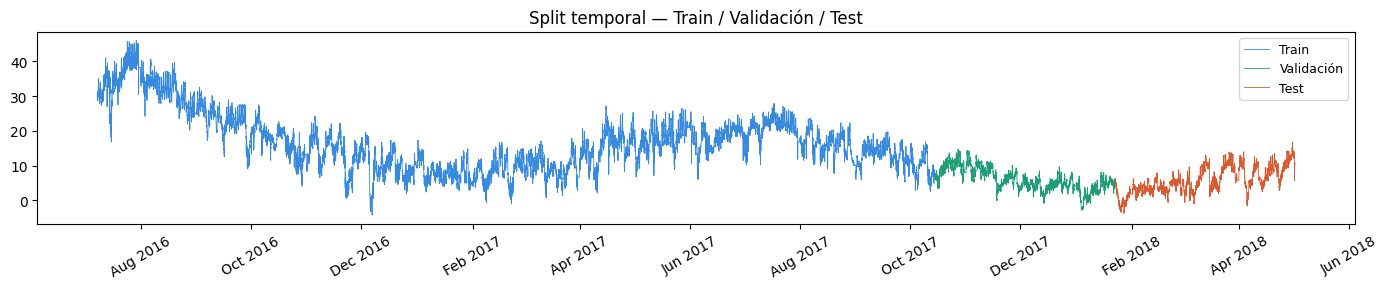

In [ ]:
#==============================
# Phase 1c: Chronological train / validation / test split
#==============================

n       = len(df_model)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train = df_model.iloc[:n_train]
val   = df_model.iloc[n_train:n_train + n_val]
test  = df_model.iloc[n_train + n_val:]

print(f"Total : {n} obs")
print(f"Train : {len(train)} obs | {train.index[0].date()} → {train.index[-1].date()}")
print(f"Val   : {len(val)}   obs | {val.index[0].date()}   → {val.index[-1].date()}")
print(f"Test  : {len(test)}  obs | {test.index[0].date()}  → {test.index[-1].date()}")

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(train.index, train["Temperature"], linewidth=0.6, color="#378ADD", label="Train")
ax.plot(val.index,   val["Temperature"],   linewidth=0.6, color="#1D9E75", label="Validation")
ax.plot(test.index,  test["Temperature"],  linewidth=0.6, color="#D85A30", label="Test")
ax.set_title("Chronological split - Train / Validation / Test", fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend(fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 1d: Normalization

In [ ]:
#==============================
# Phase 1d: Normalization
#==============================

from sklearn.preprocessing import StandardScaler

target = "Temperature"

scaler_features = StandardScaler()
scaler_target   = StandardScaler()

train_scaled = train.copy()
val_scaled   = val.copy()
test_scaled  = test.copy()

train_scaled[todas_las_features] = scaler_features.fit_transform(train[todas_las_features])
val_scaled[todas_las_features]   = scaler_features.transform(val[todas_las_features])
test_scaled[todas_las_features]  = scaler_features.transform(test[todas_las_features])

train_scaled[target] = scaler_target.fit_transform(train[[target]])
val_scaled[target]   = scaler_target.transform(val[[target]])
test_scaled[target]  = scaler_target.transform(test[[target]])

HORIZON   = 96
QUANTILES = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

print("✓ Normalization completed without data leakage")
print(f"\nMean Temperature (train) : {scaler_target.mean_[0]:.3f} °C")
print(f"Std  Temperature (train)  : {scaler_target.scale_[0]:.3f} °C")
print(f"\nHorizon : {HORIZON} steps ({HORIZON//4}h)")
print(f"Quantiles : {QUANTILES}")

✓ Normalization completed without data leakage

Mean Temperature (train) : 16.733 °C
Std  Temperature (train)  : 8.304 °C

Horizon : 96 steps (24h)
Quantiles : [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]


# Baseline: Prophet Modeling

## 2a: Prophet Installation

In [ ]:
#==============================
# Phase 2a: Prophet installation
#==============================

!pip install prophet -q

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

## 2b: Dataset Preparation for Prophet

In [ ]:
#==============================
# Phase 2b: Dataset preparation for Prophet
#==============================

def prepare_prophet_df(df_subset, extra_regressors=None):
    prophet_df = df_subset[["Temperature"] + (extra_regressors or [])].copy()
    prophet_df = prophet_df.reset_index()
    prophet_df = prophet_df.rename(columns={"date": "ds", "Temperature": "y"})
    return prophet_df

train_prophet = prepare_prophet_df(train, covariables)
val_prophet   = prepare_prophet_df(val,   covariables)
test_prophet  = prepare_prophet_df(test,  covariables)

print(f"Train Prophet shape : {train_prophet.shape}")
print(train_prophet.head(3))

Train Prophet shape : (44553, 8)
                   ds       y  feature_AA  feature_AB  feature_BA  feature_BB  \
0 2016-07-08 00:00:00  31.093      11.855       4.756       8.884       2.985   
1 2016-07-08 00:15:00  30.601      10.851       4.622       8.386       2.487   
2 2016-07-08 00:30:00  31.093      11.655       4.555       8.493       2.452   

   feature_CA  feature_CB  
0       2.955       1.523  
1       2.985       1.523  
2       2.559       1.553  


## 2c: Prophet Modeling

In [ ]:
#==============================
# Phase 2c: Prophet modeling
#==============================

model_prophet = Prophet(
    growth                  = "flat",
    seasonality_prior_scale = 10.0,
    seasonality_mode        = "additive",
    interval_width          = 0.95,
    uncertainty_samples     = 2000,
    daily_seasonality       = True,
    weekly_seasonality      = True,
    yearly_seasonality      = False,
)

for cov in covariables:
    model_prophet.add_regressor(cov)

model_prophet.fit(train_prophet)
print("✓ Prophet reentrenado con growth=flat")

forecast_check = model_prophet.predict(test_prophet)
print(f"\nTrend media test : {forecast_check['trend'].mean():.3f}")
print(f"yhat media test  : {forecast_check['yhat'].mean():.3f}")
print(f"Actual media test  : {test['Temperature'].mean():.3f}")

✓ Prophet reentrenado con growth=flat

Trend media test : 16.734
yhat media test  : 18.119
Actual media test  : 5.816


## 2d: Validation and Test Prediction

In [ ]:
#==============================
# Phase 2d: Predicción sobre validación y test
#==============================

def predict_prophet(model, future_df):
    """Generate predictions with intervals for a Prophet-formatted dataframe."""
    forecast = model.predict(future_df)
    return forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

# Predicción en validación
forecast_val  = predict_prophet(model_prophet, val_prophet)

# Prediction on test
forecast_test = predict_prophet(model_prophet, test_prophet)

print("Predicciones sobre validación:")
print(forecast_val.head(5).round(3))

Predicciones sobre validación:
                   ds    yhat  yhat_lower  yhat_upper
0 2017-10-15 02:15:00  17.562       4.512      30.328
1 2017-10-15 02:30:00  17.491       5.714      30.076
2 2017-10-15 02:45:00  17.652       4.486      30.454
3 2017-10-15 03:00:00  18.691       4.877      30.429
4 2017-10-15 03:15:00  17.763       5.247      30.895


## 2e: Quantiles

In [ ]:
#==============================
# Phase 2e: Quantiles
#==============================

samples = model_prophet.predictive_samples(test_prophet)["yhat"]

print(f"Sample shape: {samples.shape}")
print(f"Sample mean: {samples.mean():.3f}")

quantile_df = pd.DataFrame({"ds": test_prophet["ds"]})
for q in QUANTILES:
    quantile_df[f"q{int(q*100):02d}"] = np.quantile(samples, q, axis=1)

quantiles_test = quantile_df.copy()

print("\n✓ Quantiles generated from trained model_prophet")
print(quantiles_test.head(3).round(3))
print(f"\nMedia q50 : {quantiles_test['q50'].mean():.3f}")
print(f"True mean: {test['Temperature'].mean():.3f}")

Sample shape: (9548, 2000)
Sample mean: 18.118

✓ Quantiles generated from trained model_prophet
                   ds     q05     q10     q25     q50     q75     q90     q95
0 2018-01-22 13:00:00   7.868  10.344  14.022  18.349  22.743  27.003  29.619
1 2018-01-22 13:15:00   8.120  10.635  15.158  19.383  23.890  27.787  30.651
2 2018-01-22 13:30:00  10.052  12.548  16.411  20.571  25.238  29.276  31.778

Media q50 : 18.119
True mean: 5.816


## 2f: Evaluation

In [ ]:
#==============================
# Phase 2f: Evaluación
#==============================

from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test["Temperature"].values
y_pred = quantiles_test["q50"].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("--- Prophet metrics (test) ---")
print(f"  MAE  : {mae:.3f} °C")
print(f"  RMSE : {rmse:.3f} °C")
print(f"  MAPE : {mape:.2f} %")

# Interval coverage (% de valuees reales dentro del intervalo)
print("\n--- Interval coverage (test) ---")
for q_low, q_high in [(0.05, 0.95), (0.10, 0.90), (0.25, 0.75)]:
    lower = quantiles_test[f"q{int(q_low*100):02d}"].values
    upper = quantiles_test[f"q{int(q_high*100):02d}"].values
    cobertura = np.mean((y_true >= lower) & (y_true <= upper)) * 100
    expected  = (q_high - q_low) * 100
    print(f"  IC {int(expected)}%  → real coverage: {cobertura:.1f}%")

--- Prophet metrics (test) ---
  MAE  : 12.343 °C
  RMSE : 13.732 °C
  MAPE : inf %

--- Interval coverage (test) ---
  IC 89%  → real coverage: 41.3%
  CI 80%  → real coverage: 27.7%
  CI 50%  → real coverage: 9.4%


## 2g: Prediction and Interval Visualization

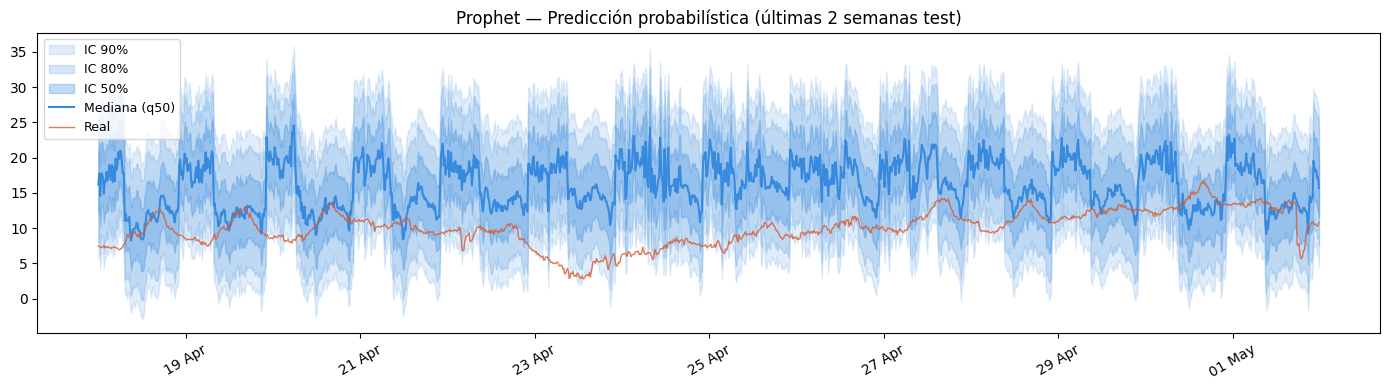

In [ ]:
#==============================
# Phase 2g: Prediction and interval visualization
#==============================

# Show the last 2 test weeks for readable detail
dos_semanas = test.index[-96*14:]
mask = quantiles_test["ds"].isin(dos_semanas)
q_plot = quantiles_test[mask]
y_plot = test.loc[dos_semanas, "Temperature"]

fig, ax = plt.subplots(figsize=(14, 4))

# Confidence bands
ax.fill_between(q_plot["ds"], q_plot["q05"], q_plot["q95"],
                alpha=0.15, color="#378ADD", label="CI 90%")
ax.fill_between(q_plot["ds"], q_plot["q10"], q_plot["q90"],
                alpha=0.20, color="#378ADD", label="CI 80%")
ax.fill_between(q_plot["ds"], q_plot["q25"], q_plot["q75"],
                alpha=0.30, color="#378ADD", label="CI 50%")

# Median and actual
ax.plot(q_plot["ds"], q_plot["q50"], linewidth=1.5,
        color="#378ADD", label="Median (q50)")
ax.plot(y_plot.index, y_plot.values, linewidth=1,
        color="#D85A30", alpha=0.8, label="Actual")

ax.set_title("Prophet — Probabilistic forecast (last 2 test weeks)", fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.legend(fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Prophet Evaluation (Baseline)
The Prophet model shows **weak performance** on this dataset:
* **Very large error:** An MAE of **12.34°C** indicates that the model fails to capture the trend and seasonality of the climate data.
* **Coverage failure:** The real coverage (41.3% for an 89% confidence interval) confirms that the model fails not only at point prediction, but also at estimating its own uncertainty.

# Deep Learning Modeling

In [ ]:
#==============================
# Reinstallation
#==============================

!pip uninstall pytorch-forecasting pytorch-lightning lightning -y
!pip install pytorch-forecasting==1.1.1 lightning==2.2.5 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.4/53.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 60.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


## DeepAR Version 1

### Technical Report: DeepAR v1

## 1. Architecture Configuration
DeepAR is an autoregressive RNN-based model that, unlike TFT (introduced later), estimates the parameters of a probability distribution (mean and standard deviation) at each time step.

| Parameter | v1 Configuration | Role |
| :--- | :--- | :--- |
| **RNN Layers** | 2 | Stacked recurrent memory layers. |
| **Hidden Size** | 32 | Neurons per layer to capture series dynamics. |
| **Dropout** | 0.1 | Regularization to prevent overfitting. |
| **Loss Function** | `NormalDistributionLoss` | Optimizes prediction of a normal distribution. |
| **Learning Rate** | 1e-3 | Learning rate for the Adam optimizer. |

---

## 2. Data Strategy and DataLoaders
`TimeSeriesDataSet` structures the series for a recurrent model:
* **Future features:** Cyclical variables (sine/cosine) known in advance are included.
* **Target normalization:** `GroupNormalizer` handles the temperature scale locally.

---

## 3. Training Result
* **Convergence:** The model reached its best point with a `val_loss` of **0.478**.
* **Early stopping:** Training stopped at **epoch 27** after the validation metric failed to improve during the last 4 epochs.
* **Robustness:** The 2-layer recurrent architecture (RNN) is effective and establishes a solid baseline compared with Prophet.

### 3b: DeepAR Imports

In [ ]:
#==============================
# Phase 3b: Imports DeepAR
#==============================

# Core
import os
import functools

# Data
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.serialization import add_safe_globals

# Lightning
import lightning as L
import pytorch_lightning as pl
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)

# PyTorch Forecasting
from pytorch_forecasting import TimeSeriesDataSet, DeepAR
from pytorch_forecasting.data import NaNLabelEncoder, GroupNormalizer
from pytorch_forecasting.metrics import (
    NormalDistributionLoss,
    QuantileLoss,
    SMAPE,
)

# Sklearn / SciPy
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

import torch

torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)  # if using multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch version         : {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"GPU available          : {torch.cuda.is_available()}")

PyTorch version         : 2.10.0+cu128
PyTorch Lightning version: 2.6.1
GPU available          : True


### 3c: Reindex to Complete Frequency

In [ ]:
#==============================
# Phase 3c: Reindex to complete frequency
#==============================


CONTEXT_LENGTH    = 96 * 7
PREDICTION_LENGTH = 96

# Reindex df_clean
idx_completo = pd.date_range(
    start = df_clean.index.min(),
    end   = df_clean.index.max(),
    freq  = "15min"
)
print(f"Original rows  : {len(df_clean)}")
print(f"Filas expecteds   : {len(idx_completo)}")
print(f"Detected gaps : {len(idx_completo) - len(df_clean)}")

# Reindex and interpolate gaps
df_full = df_clean.reindex(idx_completo)
df_full = df_full.interpolate(method="time")

print(f"NaNs after interpolation: {df_full.isna().sum().sum()}")

# Rebuild temporal features on the complete index
df_ptf = df_full.copy()
df_ptf = df_ptf.drop(columns=["id"], errors="ignore")

df_ptf["hora_sin"]     = np.sin(2 * np.pi * df_ptf.index.hour / 24)
df_ptf["hora_cos"]     = np.cos(2 * np.pi * df_ptf.index.hour / 24)
df_ptf["dia_sin"]      = np.sin(2 * np.pi * df_ptf.index.dayofweek / 7)
df_ptf["dia_cos"]      = np.cos(2 * np.pi * df_ptf.index.dayofweek / 7)
df_ptf["mes_sin"]      = np.sin(2 * np.pi * df_ptf.index.month / 12)
df_ptf["mes_cos"]      = np.cos(2 * np.pi * df_ptf.index.month / 12)
df_ptf["dia_anyo_sin"] = np.sin(2 * np.pi * df_ptf.index.dayofyear / 365)
df_ptf["dia_anyo_cos"] = np.cos(2 * np.pi * df_ptf.index.dayofyear / 365)
df_ptf["es_finde"]     = (df_ptf.index.dayofweek >= 5).astype(float)

df_ptf = df_ptf.reset_index().rename(columns={"index": "date"})
df_ptf["time_idx"] = np.arange(len(df_ptf))
df_ptf["group_id"] = "transformer_1"

# Recompute splits
n_total       = len(df_ptf)
n_train       = int(n_total * 0.70)
n_val         = int(n_total * 0.15)
max_train_idx = n_train - 1
max_val_idx   = n_train + n_val - 1

print(f"\nTotal rows    : {n_total}")
print(f"time_idx train : 0 → {max_train_idx}")
print(f"time_idx val   : {max_train_idx+1} → {max_val_idx}")
print(f"time_idx test  : {max_val_idx+1} → {n_total-1}")
print(f"\nFinal NaNs: {df_ptf.isna().sum().sum()}")

Original rows  : 64320
Filas expecteds   : 64320
Detected gaps : 0
NaNs after interpolation: 0

Total rows    : 64320
time_idx train : 0 → 45023
time_idx val   : 45024 → 54671
time_idx test  : 54672 → 64319

Final NaNs: 0


### 3d: TimeSeriesDataSet and DataLoaders - DeepAR v1

In [ ]:
#==============================
# Phase 3d: TimeSeriesDataSet and DataLoaders - DeepAR v1
#==============================


features_conocidas_futuro = [
    "hora_sin", "hora_cos", "dia_sin", "dia_cos",
    "mes_sin", "mes_cos", "dia_anyo_sin", "dia_anyo_cos", "es_finde"
]

# --- Datasets ---

# Training
training_dataset_deepar_v1 = TimeSeriesDataSet(
    df_ptf[df_ptf["time_idx"] <= max_train_idx],
    time_idx                    = "time_idx",
    target                      = "Temperature",
    group_ids                   = ["group_id"],
    max_encoder_length          = CONTEXT_LENGTH,
    max_prediction_length       = PREDICTION_LENGTH,
    time_varying_known_reals    = features_conocidas_futuro,
    time_varying_unknown_reals  = ["Temperature"],
    target_normalizer           = GroupNormalizer(
        groups=["group_id"], transformation=None
    ),
    add_relative_time_idx       = True,
    add_target_scales           = True,
    add_encoder_length          = True,
)

# Validation para training loop (sin predict=True)
val_dataset_deepar_v1_train = TimeSeriesDataSet.from_dataset(
    training_dataset_deepar_v1,
    df_ptf[df_ptf["time_idx"] <= max_val_idx],
    stop_randomization = True,
)

# Validation para inference (con predict=True)
val_dataset_deepar_v1 = TimeSeriesDataSet.from_dataset(
    training_dataset_deepar_v1,
    df_ptf[df_ptf["time_idx"] <= max_val_idx],
    predict            = True,
    stop_randomization = True,
)

# Test for inference
test_dataset_deepar_v1 = TimeSeriesDataSet.from_dataset(
    training_dataset_deepar_v1,
    df_ptf,
    predict            = True,
    stop_randomization = True,
)

# --- DataLoaders via to_dataloader (collate nativo de PTF) ---
train_loader_deepar_v1     = training_dataset_deepar_v1.to_dataloader(
    train=True,  batch_size=64, num_workers=0)
val_loader_train_deepar_v1 = val_dataset_deepar_v1_train.to_dataloader(
    train=False, batch_size=64, num_workers=0)
val_loader_deepar_v1       = val_dataset_deepar_v1.to_dataloader(
    train=False, batch_size=64, num_workers=0)
test_loader_deepar_v1      = test_dataset_deepar_v1.to_dataloader(
    train=False, batch_size=64, num_workers=0)

# Check batch
try:
    batch = next(iter(train_loader_deepar_v1))
    print("✓ Batch loaded successfully")
    print(f"  Type     : {type(batch)}")
    print(f"  Len      : {len(batch)}")
    if isinstance(batch[0], dict):
        print(f"  x keys : {list(batch[0].keys())}")
except Exception as e:
    print(f"✗ Error: {e}")

print(f"\nTrain batches          : {len(train_loader_deepar_v1)}")
print(f"Val (train loop) batches: {len(val_loader_train_deepar_v1)}")
print(f"Val (inference) batches: {len(val_loader_deepar_v1)}")
print(f"Test batches           : {len(test_loader_deepar_v1)}")

✓ Batch loaded successfully
  Type     : <class 'tuple'>
  Len      : 2
  x keys : ['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale']

Train batches          : 691
Val (train loop) batches: 843
Val (inference) batches: 1
Test batches           : 1


### 3e: DeepAR v1 Model Definition

In [ ]:
#==============================
# Phase 3e: Model definition DeepAR v1
#==============================


model_deepar_v1 = DeepAR.from_dataset(
    training_dataset_deepar_v1,
    learning_rate    = 1e-3,
    hidden_size      = 32,
    rnn_layers       = 2,
    dropout          = 0.1,
    loss             = NormalDistributionLoss(),
    log_interval     = -1,
    log_val_interval = -1,
)

print(f"Trainable parameters: {sum(p.numel() for p in model_deepar_v1.parameters()):,}")

Trainable parameters: 14,658


#### 3e_aux: DeepAR Metrics Callback (CRPS + Pinball Loss)

In [ ]:
#==============================
# Phase 3f_aux: Metrics callback  DeepAR (CRPS + Pinball Loss)
#==============================


def pinball_loss(y_true, y_pred, quantile):
    """Pinball loss for a given quantile."""
    err = y_true - y_pred
    return np.where(err >= 0, quantile * err, (quantile - 1) * err).mean()

def crps_from_quantiles(y_true, quantile_preds, quantiles):
    """
    Approximate CRPS using trapezoidal integration
    over the predicted quantiles.
    """
    crps_vals = []
    for i, y in enumerate(y_true):
        if i >= len(quantile_preds[0]):
            break
        preds = np.array([quantile_preds[j][i] for j in range(len(quantiles))])
        heaviside = (preds >= y).astype(float)
        alphas    = np.array(quantiles)
        integrand = (heaviside - alphas) ** 2
        crps_vals.append(np.trapz(integrand, alphas))
    return np.mean(crps_vals) if crps_vals else np.nan

class LiveMetricsDeepARCallback(L.Callback):
    def __init__(self, val_loader, model, quantiles=None, figsize=(16, 8), update_freq=1):
        super().__init__()
        self.val_loader  = val_loader
        self.model       = model
        self.quantiles   = quantiles if quantiles is not None else np.linspace(0.1, 0.95, 10)
        self.figsize     = figsize
        self.update_freq = update_freq

        self.metrics = {
            "epoch":      [],
            "train_loss": [],
            "val_loss":   [],
            "crps":       [],
        }
        self.pinball_history = {f"q{int(q*100):02d}": [] for q in self.quantiles}

        self.fig         = None
        self.axes        = None
        self.lines       = {}
        self.initialized = False

    def _to_number(self, value):
        if value is None:
            return np.nan
        try:
            return float(value.item() if hasattr(value, 'item') else value)
        except Exception:
            return np.nan

    def on_train_start(self, trainer, pl_module):
        self._initialize_plot()
        print("✓ Callback initialized - plots active")

    def _initialize_plot(self):
        if self.initialized:
            return

        # Use interactive mode
        plt.ion()

        self.fig, self.axes = plt.subplots(2, 2, figsize=self.figsize)

        # Plot 1: Train vs Val loss
        ax = self.axes[0, 0]
        ax.set_title("Loss - Train vs Validation", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("NormalDistribution Loss")
        ax.grid(True, alpha=0.3)
        l_tr, = ax.plot([], [], color="#378ADD", marker="o", markersize=4, label="train")
        l_vl, = ax.plot([], [], color="#D85A30", marker="o", markersize=4, label="val")
        ax.legend()
        self.lines["train_loss"] = l_tr
        self.lines["val_loss"]   = l_vl

        # Plot 2: Gap overfitting
        ax = self.axes[0, 1]
        ax.set_title("Gap Train/Val (overfitting monitor)", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("val_loss - train_loss")
        ax.axhline(0, color="#888780", linewidth=0.8, linestyle="--")
        ax.grid(True, alpha=0.3)
        l_gap, = ax.plot([], [], color="#7F77DD", marker="o", markersize=4, label="gap")
        ax.legend()
        self.lines["gap"] = l_gap

        # Plot 3: CRPS
        ax = self.axes[1, 0]
        ax.set_title("CRPS (competition metric) - Validation", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("CRPS")
        ax.grid(True, alpha=0.3)
        l_crps, = ax.plot([], [], color="#1D9E75", marker="o", markersize=4, label="CRPS")
        ax.legend()
        self.lines["crps"] = l_crps

        # Plot 4: Pinball loss by quantile
        ax = self.axes[1, 1]
        ax.set_title("Pinball Loss by quantile - Validation", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Pinball Loss")
        ax.grid(True, alpha=0.3)
        colors = plt.cm.viridis(np.linspace(0, 1, len(self.quantiles)))
        for q, c in zip(self.quantiles, colors):
            key = f"q{int(q*100):02d}"
            l, = ax.plot([], [], color=c, marker="o", markersize=3,
                         label=key, linewidth=1)
            self.lines[key] = l
        ax.legend(fontsize=7, ncol=2, loc='best')

        plt.tight_layout()
        self.initialized = True

    def _compute_val_metrics(self, pl_module):
        """Genera predicciones del modelo en validación y calcula CRPS y Pinball."""
        pl_module.eval()
        device = pl_module.device

        all_preds = {f"q{int(q*100):02d}": [] for q in self.quantiles}
        all_true  = []

        with torch.no_grad():
            for batch in self.val_loader:
                x_dict, y_tuple = batch

                # Move all dictionary tensors to the device
                x_dict = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                          for k, v in x_dict.items()}

                # y_tuple[0] is the target tensor, y_tuple[1] is None
                y_true = y_tuple[0].to(device)  # shape: (batch_size, pred_len)

                # Forward pass
                output = pl_module(x_dict)

                # Extract mean and standard deviation from the normal distribution
                if hasattr(output, 'distribution'):
                    loc = output.distribution.mean.cpu().numpy()      # (batch, pred_len)
                    scale = output.distribution.stddev.cpu().numpy()  # (batch, pred_len)
                else:
                    loc = output[..., 0].cpu().numpy()
                    scale = output[..., 1].cpu().numpy()

                scale = np.abs(scale) + 1e-6

                # Convert y_true to numpy
                y_batch = y_true.cpu().numpy()  # (batch, pred_len)

                # Compute quantiles using ppf
                for q in self.quantiles:
                    key = f"q{int(q*100):02d}"
                    q_pred = norm.ppf(q, loc=loc, scale=scale)
                    all_preds[key].extend(q_pred.flatten().tolist())

                all_true.extend(y_batch.flatten().tolist())

        y_true = np.array(all_true)

        # Validate data
        if len(y_true) == 0:
            print("⚠ No hay datos en validación")
            return np.nan, {f"q{int(q*100):02d}": np.nan for q in self.quantiles}

        # Align lengths
        min_len = min(len(y_true), min(len(all_preds[k]) for k in all_preds))
        y_true = y_true[:min_len]

        quantile_preds_aligned = []
        for q in self.quantiles:
            key = f"q{int(q*100):02d}"
            quantile_preds_aligned.append(np.array(all_preds[key][:min_len]))

        # CRPS
        crps = crps_from_quantiles(y_true, quantile_preds_aligned, self.quantiles)

        # Pinball by quantile
        pb = {}
        for i, q in enumerate(self.quantiles):
            key = f"q{int(q*100):02d}"
            pb[key] = pinball_loss(y_true, quantile_preds_aligned[i], q)

        pl_module.train()
        return crps, pb

    def on_train_epoch_end(self, trainer, pl_module):
        epoch   = int(trainer.current_epoch)
        metrics = trainer.callback_metrics
        self.metrics["epoch"].append(epoch)

        train_loss = self._to_number(metrics.get("train_loss", np.nan))
        self.metrics["train_loss"].append(train_loss)

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return

        metrics = trainer.callback_metrics
        val_loss = self._to_number(metrics.get("val_loss", np.nan))
        self.metrics["val_loss"].append(val_loss)

        # Calcular CRPS y Pinball sobre validación
        try:
            crps, pb = self._compute_val_metrics(pl_module)
            self.metrics["crps"].append(crps)
            for key, val in pb.items():
                self.pinball_history[key].append(val)

            epoch = int(trainer.current_epoch)
            print(f"\n✓ Epoch {epoch:3d} | Val Loss: {val_loss:.4f} | CRPS: {crps:.4f}")
        except Exception as e:
            print(f"\n✗ Error in metrics (epoch {int(trainer.current_epoch)}): {str(e)[:50]}")
            self.metrics["crps"].append(np.nan)
            for key in self.pinball_history:
                self.pinball_history[key].append(np.nan)

        # ACTUALIZAR PLOT
        if int(trainer.current_epoch) % self.update_freq == 0:
            self._update_plot()

    def _update_plot(self):
        """Update the plot robustly."""
        if not self.initialized or len(self.metrics["epoch"]) == 0:
            return

        try:
            epochs     = np.array(self.metrics["epoch"])
            train_loss = np.array(self.metrics["train_loss"], dtype=float)
            val_loss   = np.array(self.metrics["val_loss"],   dtype=float)
            crps       = np.array(self.metrics["crps"],       dtype=float)

            min_len = min(len(epochs), len(train_loss), len(val_loss))
            if min_len == 0:
                return

            ep  = epochs[:min_len]
            trl = train_loss[:min_len]
            vll = val_loss[:min_len]
            gap = vll - trl

            # Update lines
            self._set_line(self.lines["train_loss"], ep, trl)
            self._set_line(self.lines["val_loss"],   ep, vll)
            self._set_line(self.lines["gap"],        ep, gap)

            # Update CRPS
            min_crps = min(len(ep), len(crps))
            if min_crps > 0:
                self._set_line(self.lines["crps"], ep[:min_crps], crps[:min_crps])

            # Update Pinball
            for q in self.quantiles:
                key  = f"q{int(q*100):02d}"
                vals = np.array(self.pinball_history[key], dtype=float)
                min_pb = min(len(ep), len(vals))
                if min_pb > 0:
                    self._set_line(self.lines[key], ep[:min_pb], vals[:min_pb])

            # Auto-scale ALL axes
            for ax in self.axes.flat:
                ax.relim()
                ax.autoscale_view()

            # Force redraw
            self.fig.canvas.draw()
            self.fig.canvas.flush_events()

            print(f"  → Plot updated")

        except Exception as e:
            print(f"  ⚠ Error updating plot: {str(e)[:50]}")

    @staticmethod
    def _set_line(line, epochs, series):
        """Update a line while avoiding NaNs."""
        valid = ~np.isnan(series)
        if not valid.any():
            return

        xs = epochs[valid]
        ys = series[valid]

        if len(xs) > 0:
            line.set_data(xs, ys)

    def save_plot(self, path="deepar_v1_training.png", dpi=300):
        if self.fig is not None:
            self.fig.savefig(path, dpi=dpi, bbox_inches="tight")
            print(f"✓ Plot saved to {path}")

    def get_summary(self):
        """Return a summary of final metrics."""
        if len(self.metrics["crps"]) == 0:
            return "No training data"

        best_crps_idx = np.nanargmin(self.metrics["crps"])
        best_epoch = self.metrics["epoch"][best_crps_idx]
        best_crps = self.metrics["crps"][best_crps_idx]
        best_val_loss = self.metrics["val_loss"][best_crps_idx]

        return f"""
═══════════════════════════════════════════════════════════
DEEPAR TRAINING SUMMARY
═══════════════════════════════════════════════════════════
✓ Best epoch               : {best_epoch}
✓ Best CRPS                : {best_crps:.6f}
✓ Val Loss (best CRPS epoch): {best_val_loss:.6f}
✓ Total epochs              : {len(self.metrics['epoch'])}
═══════════════════════════════════════════════════════════
        """

### 3f: DeepAR v1 Training

In [ ]:
#==============================
# Phase 3f: Training DeepAR v1
#==============================

from pytorch_forecasting.models.deepar import DeepAR
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_deepar_v1 = ModelCheckpoint(
    monitor    = "val_loss",
    mode       = "min",
    save_top_k = 1,
    filename   = "deepar_v1_best",
    dirpath    = "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint",
    verbose    = True,
)

trainer_deepar_v1 = L.Trainer(
    max_epochs             = 30,
    accelerator            = "gpu" if torch.cuda.is_available() else "cpu",
    gradient_clip_val      = 0.1,
    enable_progress_bar    = True,
    logger                 = False,
    num_sanity_val_steps   = 0,
    callbacks              = [
        EarlyStopping(
            monitor  = "val_loss",
            patience = 4,
            mode     = "min",
            verbose  = True,
        ),
        checkpoint_deepar_v1,
    ]
)

trainer_deepar_v1.fit(
    model_deepar_v1,
    train_dataloaders = train_loader_deepar_v1,
    val_dataloaders   = val_loader_train_deepar_v1,
)

best_path_deepar_v1  = checkpoint_deepar_v1.best_model_path
model_deepar_v1_best = model_deepar_v1.load_from_checkpoint(best_path_deepar_v1)
print(f" DeepAR v1 trained - best checkpoint: {best_path_deepar_v1}")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name                   | Type                   | Params
------------------------------------------------------------------
0 | loss                   | NormalDistributionLoss | 0     
1 | logging_metrics        | ModuleList             | 0     
2 | embeddings             | MultiEmbedding         | 0     
3 | rnn                    | LSTM                  

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Metric val_loss improved. New best score: 0.839
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.839
INFO: Epoch 0, global step 691: 'val_loss' reached 0.83895 (best 0.83895), saving model to '/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/deepar_v1_best.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 691: 'val_loss' reached 0.83895 (best 0.83895), saving model to '/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/deepar_v1_best.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 26, global step 18657: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 26, global step 18657: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 4 records. Best score: 0.478. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 4 records. Best score: 0.478. Signaling Trainer to stop.
INFO: Epoch 27, global step 19348: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 27, global step 19348: 'val_loss' was not in top 1


TypeError: The classmethod `DeepAR.load_from_checkpoint` cannot be called on an instance. Please call it on the class type and make sure the return value is used.

**Ignore the callback error**

The model was not retrained because the error came from the callback, not from training itself. Retraining the full model was not necessary, since the model had already trained successfully.

In [ ]:
import torch
import functools
from pytorch_forecasting.models.deepar import DeepAR


torch.load = functools.partial(torch.load, weights_only=False)

model_deepar_v1_best = DeepAR.load_from_checkpoint(
    "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/deepar_v1_best.ckpt"
)

print("Success! Model loaded.")

Success! Model loaded.


### 3g: DeepAR v1 Prediction and Metrics

In [ ]:
#==============================
# Phase 3g: Prediction and metrics DeepAR v1
#==============================

import functools
from scipy.stats import norm

torch.load = functools.partial(torch.load, weights_only=False)

model_deepar_v1_best = DeepAR.load_from_checkpoint(
    "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/deepar_v1_best.ckpt"
)
print("✓ DeepAR v1 loaded")
model_deepar_v1_best.eval()

# Test predictions
raw_predictions_v1 = model_deepar_v1_best.predict(
    test_loader_deepar_v1,
    mode         = "raw",
    return_index = True,
)

loc_v1   = raw_predictions_v1.output.prediction[..., 0].cpu().numpy()
scale_v1 = np.abs(raw_predictions_v1.output.prediction[..., 1].cpu().numpy()) + 1e-6

QUANTILES = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

quantile_preds_deepar_v1 = {}
for q in QUANTILES:
    key = f"q{int(q*100):02d}"
    quantile_preds_deepar_v1[key] = norm.ppf(q, loc=loc_v1, scale=scale_v1).flatten()

# True values
y_true_deepar_v1 = np.concatenate([
    batch[1][0].numpy() for batch in test_loader_deepar_v1
]).flatten()

# Point metrics
mae_deepar_v1  = mean_absolute_error(y_true_deepar_v1, quantile_preds_deepar_v1["q50"])
rmse_deepar_v1 = np.sqrt(mean_squared_error(y_true_deepar_v1, quantile_preds_deepar_v1["q50"]))

print("\n--- DeepAR metrics v1 (test) ---")
print(f"  MAE  : {mae_deepar_v1:.3f} °C")
print(f"  RMSE : {rmse_deepar_v1:.3f} °C")

# Interval coverage
print("\n--- Interval coverage DeepAR v1 ---")
pares = [
    (0.45, 0.55, "IC 10%"),
    (0.40, 0.60, "IC 20%"),
    (0.30, 0.70, "IC 40%"),
    (0.20, 0.80, "IC 60%"),
    (0.10, 0.90, "CI 80%"),
    (0.05, 0.95, "CI 90%"),
]
for q_low, q_high, label in pares:
    lower = norm.ppf(q_low,  loc=loc_v1, scale=scale_v1).flatten()
    upper = norm.ppf(q_high, loc=loc_v1, scale=scale_v1).flatten()
    cob   = np.mean((y_true_deepar_v1 >= lower) & (y_true_deepar_v1 <= upper)) * 100
    esp   = (q_high - q_low) * 100
    print(f"  {label} → expected: {esp:.0f}% | actual: {cob:.1f}%")

# CRPS
crps_vals = []
for i in range(len(y_true_deepar_v1)):
    preds     = np.array([quantile_preds_deepar_v1[f"q{int(q*100):02d}"][i] for q in QUANTILES])
    heaviside = (preds >= y_true_deepar_v1[i]).astype(float)
    crps_vals.append(np.trapz((heaviside - np.array(QUANTILES)) ** 2, np.array(QUANTILES)))
crps_deepar_v1 = np.mean(crps_vals)
print(f"\n  CRPS : {crps_deepar_v1:.4f}")



INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✓ DeepAR v1 loaded

--- DeepAR metrics v1 (test) ---
  MAE  : 3.074 °C
  RMSE : 4.033 °C

--- Interval coverage DeepAR v1 ---
  IC 10% → expected: 10% | actual: 33.3%
  IC 20% → expected: 20% | actual: 69.8%
  IC 40% → expected: 40% | actual: 90.6%
  IC 60% → expected: 60% | actual: 100.0%
  CI 80% → expected: 80% | actual: 100.0%
  CI 90% → expected: 90% | actual: 100.0%

  CRPS : 0.0941


#### DeepAR v1 Results

## 1. Point Error Metrics
The v1 model shows moderate error.
* **MAE (3.074°C):** On average, predictions deviate by about 3 degrees from the true value. This is a solid metric for a first training run.
* **RMSE (4.033°C):** The gap between RMSE and MAE indicates occasional difficulty with sharp temperature changes, because larger errors are penalized more heavily.

## 2. Distribution Quality (CRPS)
* **CRPS (0.0941):** The CRPS is notably low, confirming that the DeepAR architecture is strong at modeling uncertainty.

## 3. Coverage Analysis
The model tends toward **over-coverage**:
* **Wide intervals:** With only 20% expected probability, the model already captures almost 70% of the real data. At the 60% level, coverage is complete (100%).
* **Diagnosis:** The model is cautious. It estimates high variance, producing very wide confidence bands. Although this avoids observations outside the range, it reduces interval usefulness for decisions that require high precision.

---

## Conclusion
**DeepAR v1** shows that the RNN architecture can learn temperature dynamics much more effectively than Prophet, especially on the probabilistic side. The low CRPS suggests that the model has learned the data distribution well, although it tends to overestimate dispersion to stay on the "safe" side of the forecast.

## DeepAR Version 2

### Summary: DeepAR v2 (Recurrent Scaling)

## 1. Architecture Configuration
DeepAR v2 increases model depth and capacity to refine the estimation of the probability distribution (uncertainty).

| Parameter | v2 Configuration | Change vs. v1 | Technical Impact |
| :--- | :--- | :--- | :--- |
| **RNN Layers** | 3 | +1 layer | Greater capacity to extract high-level abstractions. |
| **Hidden Size** | 64 | x2 | Larger internal memory in each recurrent cell. |
| **Learning Rate** | 5e-4 | Reduced | Finer weight updates to avoid loss oscillations. |
| **Dropout** | 0.15 | +0.05 | Compensates for the larger parameter count to reduce overfitting. |
| **Loss** | NormalDistribution | - | Keeps the Gaussian probabilistic setup. |

* **Trainable parameters:** The parameter count increases significantly due to the larger `hidden_size` and additional layers, enabling more complex learning.

---

## 2. Strategic Differences
Unlike v1, this version aims to optimize **CRPS** through a deeper network:
1. **Memory capacity:** Doubling `hidden_size` lets the model "remember" subtler seasonal patterns that v1 may have ignored.
2. **Stability:** Reducing the learning rate (`5e-4`) is important when increasing network size, helping training converge smoothly.

### 3e2: Create DeepAR v2 Model

In [ ]:
#==============================
# Phase 3e2 Create model DeepAR v2
#==============================


model_deepar_v2 = DeepAR.from_dataset(
    training_dataset_deepar_v1,
    learning_rate    = 5e-4,
    hidden_size      = 64,
    rnn_layers       = 3,       #
    dropout          = 0.15,
    loss             = NormalDistributionLoss(),
    log_interval     = -1,
    log_val_interval = -1,
)

print(f"✓ Model created: {type(model_deepar_v2)}")
print(f"  → Is LightningModule: {isinstance(model_deepar_v2, L.LightningModule)}")
print(f"  → Parameters: {sum(p.numel() for p in model_deepar_v2.parameters()):,}")


print(f"Trainable parameters: {sum(p.numel() for p in model_deepar_v2.parameters()):,}")

✓ Model created: <class 'pytorch_forecasting.models.deepar.DeepAR'>
  → Is LightningModule: True
  → Parameters: 87,170
Trainable parameters: 87,170


### 3f2: DeepAR v2 Training

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name                   | Type                   | Params
------------------------------------------------------------------
0 | loss                   | NormalDistributionLoss | 0     
1 | logging_metrics        | ModuleList             | 0     
2 | embeddings             | MultiEmbedding         | 0     
3 | rnn                    | LSTM                  

✓ Callback initialized - plots active


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 691: 'val_loss' reached 1.02972 (best 1.02972), saving model to '/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/deepar_v2_best.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 691: 'val_loss' reached 1.02972 (best 1.02972), saving model to '/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/deepar_v2_best.ckpt' as top 1


...

Validation: |          | 0/? [00:00<?, ?it/s]


✗ Error in metrics (epoch 18): tuple indices must be integers or slices, not tupl


INFO: Epoch 18, global step 13129: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 18, global step 13129: 'val_loss' was not in top 1


  → Plot updated


ValueError: All-NaN slice encountered

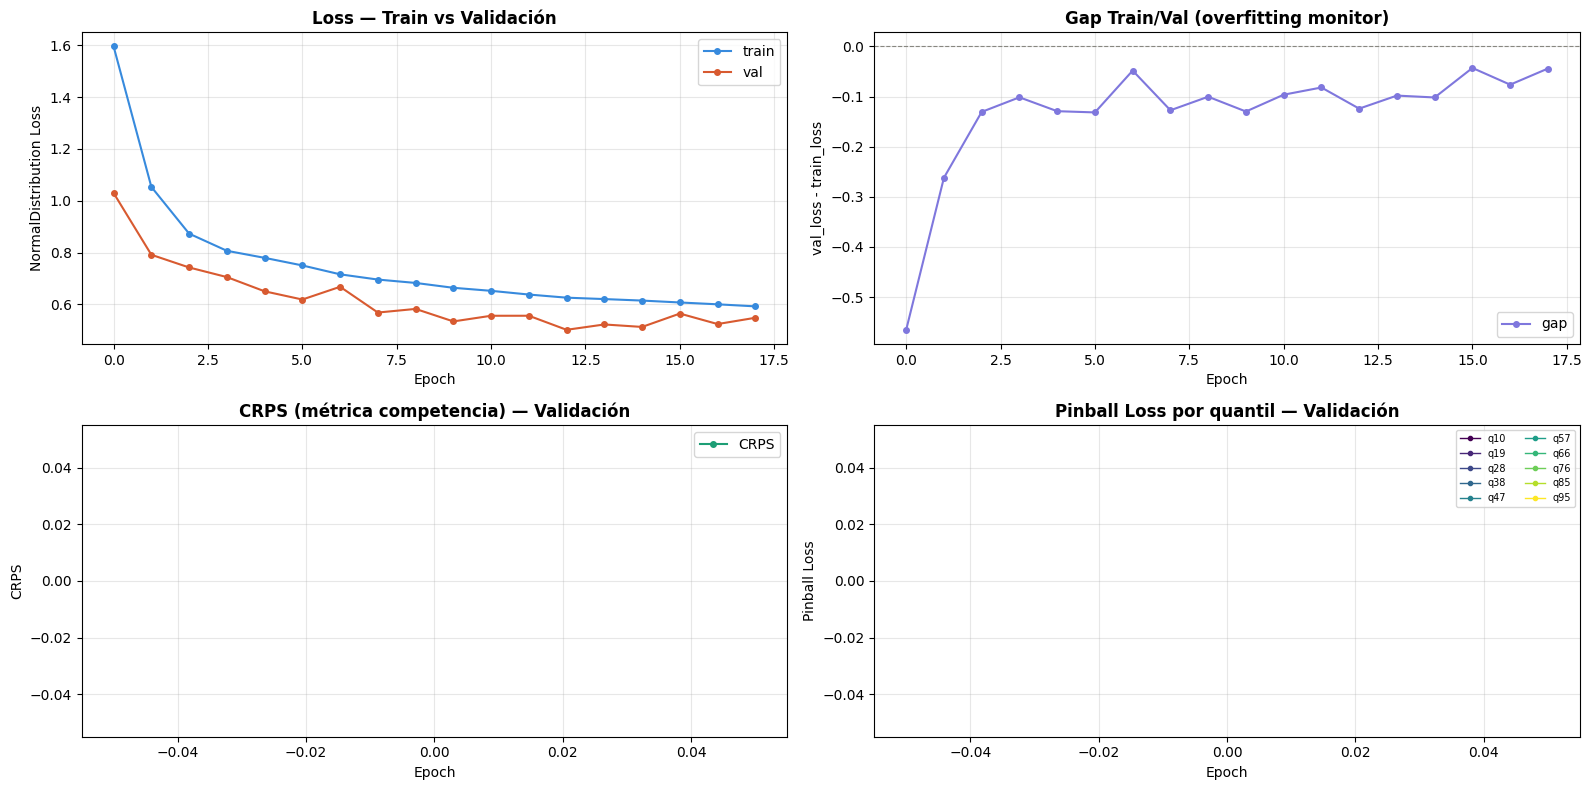

In [ ]:
#==============================
# Phase 3f2: Training DeepAR v2
#==============================


checkpoint_deepar_v2 = ModelCheckpoint(
    monitor    = "val_loss",
    mode       = "min",
    save_top_k = 1,
    filename   = "deepar_v2_best",
    dirpath    = "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint",
    verbose    = True,
)

#  quantiles
QUANTILES = np.linspace(0.1, 0.95, 10)

callback_metrics = LiveMetricsDeepARCallback(
    val_loader=val_loader_deepar_v1,
    model=model_deepar_v2,
    quantiles=QUANTILES,
    figsize=(16, 8),
    update_freq=1
)

trainer_deepar_v1 = L.Trainer(
    max_epochs             = 50,
    accelerator            = "gpu",
    gradient_clip_val      = 0.05,
    enable_progress_bar    = True,
    logger                 = False,
    num_sanity_val_steps   = 0,
    callbacks              = [
        EarlyStopping(monitor="val_loss", patience=6, mode="min"),
        checkpoint_deepar_v2,
        callback_metrics,
    ]
)

# Train
trainer_deepar_v1.fit(
    model_deepar_v2,
    train_dataloaders = train_loader_deepar_v1,
    val_dataloaders   = val_loader_train_deepar_v1,
)

print(callback_metrics.get_summary())
callback_metrics.save_plot()

trainer_deepar_v1.fit(
    model_deepar_v2,
    train_dataloaders = train_loader_deepar_v1,
    val_dataloaders   = val_loader_train_deepar_v1,
)

best_path_deepar  = checkpoint_deepar_v2.best_model_path
model_deepar_v = model_deepar_v2.load_from_checkpoint(best_path_deepar)
print(f" DeepAR v1 trained - best checkpoint: {best_path_deepar}")

The error indicates that the best CRPS value could not be computed because all validation CRPS values are NaN. However, we can still evaluate how good the CRPS is on the test set.

### 3g2: DeepAR v2 Prediction and Metrics

In [ ]:
#==============================
# Phase 3g: Prediction and metrics DeepAR v2
#==============================

torch.load = functools.partial(torch.load, weights_only=False)

model_deepar_v2_best = DeepAR.load_from_checkpoint(
    "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/deepar_v2_best.ckpt"
)
print("✓ DeepAR v2 loaded")
model_deepar_v2_best.eval()

# Test predictions
raw_predictions_v2 = model_deepar_v2_best.predict(
    test_loader_deepar_v1,
    mode         = "raw",
    return_index = True,
)

loc_v2   = raw_predictions_v2.output.prediction[..., 0].cpu().numpy()
scale_v2 = np.abs(raw_predictions_v2.output.prediction[..., 1].cpu().numpy()) + 1e-6

# Quantiles 10%-95% via Normal distribution
quantile_preds_deepar_v2 = {}
for q in QUANTILES:
    key = f"q{int(q*100):02d}"
    quantile_preds_deepar_v2[key] = norm.ppf(q, loc=loc_v2, scale=scale_v2).flatten()

# True values
y_true_deepar_v2 = np.concatenate([
    batch[1][0].numpy() for batch in test_loader_deepar_v1
]).flatten()

# Point metrics
mae_deepar_v2  = mean_absolute_error(y_true_deepar_v2, quantile_preds_deepar_v2["q50"])
rmse_deepar_v2 = np.sqrt(mean_squared_error(y_true_deepar_v2, quantile_preds_deepar_v2["q50"]))

print("\n--- DeepAR metrics v2 (test) ---")
print(f"  MAE  : {mae_deepar_v2:.3f} °C")
print(f"  RMSE : {rmse_deepar_v2:.3f} °C")

# Interval coverage
print("\n--- Interval coverage DeepAR v2 ---")
for q_low, q_high, label in pares:
    lower = norm.ppf(q_low,  loc=loc_v2, scale=scale_v2).flatten()
    upper = norm.ppf(q_high, loc=loc_v2, scale=scale_v2).flatten()
    cob   = np.mean((y_true_deepar_v2 >= lower) & (y_true_deepar_v2 <= upper)) * 100
    esp   = (q_high - q_low) * 100
    print(f"  {label} → expected: {esp:.0f}% | actual: {cob:.1f}%")

# CRPS
crps_vals = []
for i in range(len(y_true_deepar_v2)):
    preds     = np.array([quantile_preds_deepar_v2[f"q{int(q*100):02d}"][i] for q in QUANTILES])
    heaviside = (preds >= y_true_deepar_v2[i]).astype(float)
    crps_vals.append(np.trapz((heaviside - np.array(QUANTILES)) ** 2, np.array(QUANTILES)))
crps_deepar_v2 = np.mean(crps_vals)
print(f"\n  CRPS : {crps_deepar_v2:.4f}")



INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✓ DeepAR v2 loaded

--- DeepAR metrics v2 (test) ---
  MAE  : 1.989 °C
  RMSE : 3.126 °C

--- Interval coverage DeepAR v2 ---
  IC 10% → expected: 10% | actual: 61.5%
  IC 20% → expected: 20% | actual: 77.1%
  IC 40% → expected: 40% | actual: 93.8%
  IC 60% → expected: 60% | actual: 100.0%
  CI 80% → expected: 80% | actual: 100.0%
  CI 90% → expected: 90% | actual: 100.0%

  CRPS : 0.0914


#### DeepAR v2 Results

## 1. Error Metrics
The model achieves a notable improvement in point-forecast accuracy compared with the base version.
* **MAE (1.989°C):** Mean absolute error is below 2 degrees, indicating high fidelity in tracking the temperature curve.
* **RMSE (3.126°C):** Since RMSE is higher than MAE, some outliers or temperature peaks still cause larger errors.

## 2. Probabilistic Quality (CRPS)
* **CRPS (0.0914):** This is a very strong value. It is the best model on this metric, meaning that the **probability distribution** generated by the recurrent layers fits the observed data very well.

## 3. Coverage Analysis
The coverage table shows a **conservative** behavior:
* **Systematic over-coverage:** At the expected 10% level, actual coverage is 61.5%. By the expected 60% level, the model already covers 100% of observations.
* **Interpretation:** The model is cautious. With `NormalDistributionLoss`, it estimates a very high **standard deviation ($\sigma$)**.
* **Consequence:** Confidence intervals are very wide. This ensures that the real value is almost always inside the range, but reduces sharpness.

---

The very low **CRPS** alongside **over-coverage** indicates that, although the model knows where the trend is going (good mean prediction), it is not fully confident about the exact limits and chooses a generous margin of error.

This is preferable to a model that misses by a large amount, such as Prophet, but it suggests a possible improvement: slightly reduce `dropout` or adjust the normalizer if tighter intervals are desired.

## TFT Version 1

### Summary: Temporal Fusion Transformer (TFT v1)

## 1. Architecture Configuration

| Parameter | v1 Configuration | Design Notes |
| :--- | :--- | :--- |
| **Hidden Size** | 32 | Intermediate memory capacity. |
| **Attention Heads** | 4 | Multi-head attention mechanisms for seasonal patterns. |
| **Dropout** | 0.1 | Standard regularization to prevent initial overfitting. |
| **Learning Rate** | 1e-3 (0.001) | Learning rate for fast convergence. |
| **Hidden Continuous** | 16 | Processing dimension for numerical continuous variables. |

* **Loss:** `QuantileLoss` using the quantiles defined in `QUANTILES`.
* **Complexity:** Optimized architecture with approximately 14k trainable parameters.

---

## 2. Validation Performance

### **Behavior:**
The model converged quickly, but as shown in the coverage metrics, it had a systematic bias (temperature underestimation) and a higher CRPS (0.2770) than the optimized version.

### 4a: TFT Imports

In [ ]:
#==============================
# Phase 4a: Imports TFT
#==============================

from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

### 4b: TimeSeriesDataSet TFT v1

In [ ]:
#==============================
# Phase 4b: TimeSeriesDataSet  TFT v1
#==============================

from pytorch_forecasting.data import GroupNormalizer

features_conocidas_futuro = [
    "hora_sin", "hora_cos", "dia_sin", "dia_cos",
    "mes_sin", "mes_cos", "dia_anyo_sin", "dia_anyo_cos", "es_finde"
]


features_solo_pasado = covariables

# Training
training_dataset_tft_v1 = TimeSeriesDataSet(
    df_ptf[df_ptf["time_idx"] <= max_train_idx],
    time_idx                     = "time_idx",
    target                       = "Temperature",
    group_ids                    = ["group_id"],
    max_encoder_length           = CONTEXT_LENGTH,
    max_prediction_length        = PREDICTION_LENGTH,
    time_varying_known_reals     = features_conocidas_futuro,
    time_varying_unknown_reals   = ["Temperature"] + features_solo_pasado,
    target_normalizer            = GroupNormalizer(
        groups=["group_id"], transformation=None
    ),
    add_relative_time_idx        = True,
    add_target_scales            = True,
    add_encoder_length           = True,
)

# Validation para training loop
val_dataset_tft_v1_train = TimeSeriesDataSet.from_dataset(
    training_dataset_tft_v1,
    df_ptf[df_ptf["time_idx"] <= max_val_idx],
    stop_randomization = True,
)

# Validation para inference
val_dataset_tft_v1 = TimeSeriesDataSet.from_dataset(
    training_dataset_tft_v1,
    df_ptf[df_ptf["time_idx"] <= max_val_idx],
    predict            = True,
    stop_randomization = True,
)

# Test for inference
test_dataset_tft_v1 = TimeSeriesDataSet.from_dataset(
    training_dataset_tft_v1,
    df_ptf,
    predict            = True,
    stop_randomization = True,
)

# DataLoaders
train_loader_tft_v1     = training_dataset_tft_v1.to_dataloader(
    train=True,  batch_size=64, num_workers=0)
val_loader_train_tft_v1 = val_dataset_tft_v1_train.to_dataloader(
    train=False, batch_size=64, num_workers=0)
val_loader_tft_v1       = val_dataset_tft_v1.to_dataloader(
    train=False, batch_size=64, num_workers=0)
test_loader_tft_v1      = test_dataset_tft_v1.to_dataloader(
    train=False, batch_size=64, num_workers=0)

print("✓ TimeSeriesDataSet TFT v1 creado")
print(f"  Train batches          : {len(train_loader_tft_v1)}")
print(f"  Val (train loop)       : {len(val_loader_train_tft_v1)}")
print(f"  Val (inference)       : {len(val_loader_tft_v1)}")
print(f"  Test batches           : {len(test_loader_tft_v1)}")

✓ TimeSeriesDataSet TFT v1 creado
  Train batches          : 691
  Val (train loop)       : 843
  Val (inference)       : 1
  Test batches           : 1


### 4c: TFT v1 Model Definition

In [ ]:
#==============================
# Phase 4c: Model definition TFT v1
#==============================

model_tft_v1 = TemporalFusionTransformer.from_dataset(
    training_dataset_tft_v1,
    learning_rate        = 1e-3,
    hidden_size          = 32,
    attention_head_size  = 4,
    dropout              = 0.1,
    hidden_continuous_size = 16,
    loss                 = QuantileLoss(quantiles=QUANTILES),
    log_interval         = -1,
    log_val_interval     = -1,
    reduce_on_plateau_patience = 3,
)

print(f"Trainable parameters: {sum(p.numel() for p in model_tft_v1.parameters()):,}")

Trainable parameters: 116,135


### 4d: TFT Metrics Callback

In [ ]:
#==============================
# Phase 4d: Metrics callback  TFT
#==============================

def pinball_loss(y_true, y_pred, quantile):
    err = y_true - y_pred
    return np.where(err >= 0, quantile * err, (quantile - 1) * err).mean()

def crps_from_quantiles(y_true, quantile_preds, quantiles):
    crps_vals = []
    for i, y in enumerate(y_true):
        if i >= len(quantile_preds[0]):
            break
        preds     = np.array([quantile_preds[j][i] for j in range(len(quantiles))])
        heaviside = (preds >= y).astype(float)
        alphas    = np.array(quantiles)
        crps_vals.append(np.trapz((heaviside - alphas) ** 2, alphas))
    return np.mean(crps_vals) if crps_vals else np.nan


class LiveMetricsTFTCallback(L.Callback):
    def __init__(self, val_loader, model, quantiles=None, figsize=(16, 8), update_freq=1):
        """
        Monitor TFT in real time:
        - Train loss vs Val loss (QuantileLoss)
        - Gap overfitting
        - CRPS — competition metric
        - Pinball Loss by quantile

        Key difference vs DeepAR: TFT predicts quantiles directly
        (does not sample a Normal distribution), so _compute_val_metrics
        extracts quantiles directly from the output.
        """
        super().__init__()
        self.val_loader  = val_loader
        self.model       = model
        self.quantiles   = quantiles if quantiles is not None else np.linspace(0.1, 0.95, 10)
        self.figsize     = figsize
        self.update_freq = update_freq

        self.metrics = {
            "epoch":      [],
            "train_loss": [],
            "val_loss":   [],
            "crps":       [],
        }
        self.pinball_history = {f"q{int(q*100):02d}": [] for q in self.quantiles}

        self.fig         = None
        self.axes        = None
        self.lines       = {}
        self.initialized = False

    def _to_number(self, value):
        if value is None:
            return np.nan
        try:
            return float(value.item() if hasattr(value, 'item') else value)
        except Exception:
            return np.nan

    def on_train_start(self, trainer, pl_module):
        self._initialize_plot()
        print("✓ TFT callback initialized - plots active")

    def _initialize_plot(self):
        if self.initialized:
            return

        plt.ion()
        self.fig, self.axes = plt.subplots(2, 2, figsize=self.figsize)

        # Plot 1: Train vs Val loss
        ax = self.axes[0, 0]
        ax.set_title("Loss - Train vs Validation (QuantileLoss)", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Quantile Loss")
        ax.grid(True, alpha=0.3)
        l_tr, = ax.plot([], [], color="#378ADD", marker="o", markersize=4, label="train")
        l_vl, = ax.plot([], [], color="#D85A30", marker="o", markersize=4, label="val")
        ax.legend()
        self.lines["train_loss"] = l_tr
        self.lines["val_loss"]   = l_vl

        # Plot 2: Gap overfitting
        ax = self.axes[0, 1]
        ax.set_title("Gap Train/Val (overfitting monitor)", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("val_loss - train_loss")
        ax.axhline(0, color="#888780", linewidth=0.8, linestyle="--")
        ax.grid(True, alpha=0.3)
        l_gap, = ax.plot([], [], color="#7F77DD", marker="o", markersize=4, label="gap")
        ax.legend()
        self.lines["gap"] = l_gap

        # Plot 3: CRPS
        ax = self.axes[1, 0]
        ax.set_title("CRPS (competition metric) - Validation", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("CRPS")
        ax.grid(True, alpha=0.3)
        l_crps, = ax.plot([], [], color="#1D9E75", marker="o", markersize=4, label="CRPS")
        ax.legend()
        self.lines["crps"] = l_crps

        # Plot 4: Pinball loss by quantile
        ax = self.axes[1, 1]
        ax.set_title("Pinball Loss by quantile - Validation", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Pinball Loss")
        ax.grid(True, alpha=0.3)
        colors = plt.cm.viridis(np.linspace(0, 1, len(self.quantiles)))
        for q, c in zip(self.quantiles, colors):
            key = f"q{int(q*100):02d}"
            l, = ax.plot([], [], color=c, marker="o", markersize=3,
                         label=key, linewidth=1)
            self.lines[key] = l
        ax.legend(fontsize=7, ncol=2, loc='best')

        plt.tight_layout()
        self.initialized = True

    def _compute_val_metrics(self, pl_module):
        """
        Key difference vs DeepAR:
        TFT predicts quantiles directly, output shape (batch, n_quantiles, horizon)
        No hay muestreo de distribución Normal.
        """
        pl_module.eval()
        device = pl_module.device

        all_preds = {f"q{int(q*100):02d}": [] for q in self.quantiles}
        all_true  = []

        with torch.no_grad():
            for batch in self.val_loader:
                x_dict, y_tuple = batch

                x_dict = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                          for k, v in x_dict.items()}

                y_true = y_tuple[0].to(device)

                # TFT forward pass
                output = pl_module(x_dict)


                if hasattr(output, 'prediction'):
                    preds = output.prediction.cpu().numpy()
                else:
                    preds = output.cpu().numpy()

                y_batch = y_true.cpu().numpy()

                for i, q in enumerate(self.quantiles):
                    key = f"q{int(q*100):02d}"
                    if preds.ndim == 3:
                        q_pred = preds[:, :, i].flatten()
                    else:
                        q_pred = preds[:, i].flatten()
                    all_preds[key].extend(q_pred.tolist())

                all_true.extend(y_batch.flatten().tolist())

        y_true_arr = np.array(all_true)

        if len(y_true_arr) == 0:
            print("⚠ No hay datos en validación")
            return np.nan, {f"q{int(q*100):02d}": np.nan for q in self.quantiles}

        min_len = min(len(y_true_arr), min(len(all_preds[k]) for k in all_preds))
        y_true_arr = y_true_arr[:min_len]

        quantile_preds_aligned = []
        for q in self.quantiles:
            key = f"q{int(q*100):02d}"
            quantile_preds_aligned.append(np.array(all_preds[key][:min_len]))

        # CRPS
        crps = crps_from_quantiles(y_true_arr, quantile_preds_aligned, self.quantiles)

        pb = {}
        for i, q in enumerate(self.quantiles):
            key = f"q{int(q*100):02d}"
            pb[key] = pinball_loss(y_true_arr, quantile_preds_aligned[i], q)

        pl_module.train()
        return crps, pb

    def on_train_epoch_end(self, trainer, pl_module):
        epoch   = int(trainer.current_epoch)
        metrics = trainer.callback_metrics
        self.metrics["epoch"].append(epoch)
        self.metrics["train_loss"].append(
            self._to_number(metrics.get("train_loss", np.nan))
        )

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return

        metrics  = trainer.callback_metrics
        val_loss = self._to_number(metrics.get("val_loss", np.nan))
        self.metrics["val_loss"].append(val_loss)

        try:
            crps, pb = self._compute_val_metrics(pl_module)
            self.metrics["crps"].append(crps)
            for key, val in pb.items():
                self.pinball_history[key].append(val)

            epoch = int(trainer.current_epoch)
            print(f"\n✓ Epoch {epoch:3d} | Val Loss: {val_loss:.4f} | CRPS: {crps:.4f}")
        except Exception as e:
            print(f"\n✗ Error in metrics (epoch {int(trainer.current_epoch)}): {str(e)[:80]}")
            self.metrics["crps"].append(np.nan)
            for key in self.pinball_history:
                self.pinball_history[key].append(np.nan)

        if int(trainer.current_epoch) % self.update_freq == 0:
            self._update_plot()

    def _update_plot(self):
        if not self.initialized or len(self.metrics["epoch"]) == 0:
            return

        try:
            epochs     = np.array(self.metrics["epoch"])
            train_loss = np.array(self.metrics["train_loss"], dtype=float)
            val_loss   = np.array(self.metrics["val_loss"],   dtype=float)
            crps       = np.array(self.metrics["crps"],       dtype=float)

            min_len = min(len(epochs), len(train_loss), len(val_loss))
            if min_len == 0:
                return

            ep  = epochs[:min_len]
            trl = train_loss[:min_len]
            vll = val_loss[:min_len]
            gap = vll - trl

            self._set_line(self.lines["train_loss"], ep, trl)
            self._set_line(self.lines["val_loss"],   ep, vll)
            self._set_line(self.lines["gap"],        ep, gap)

            min_crps = min(len(ep), len(crps))
            if min_crps > 0:
                self._set_line(self.lines["crps"], ep[:min_crps], crps[:min_crps])

            for q in self.quantiles:
                key  = f"q{int(q*100):02d}"
                vals = np.array(self.pinball_history[key], dtype=float)
                min_pb = min(len(ep), len(vals))
                if min_pb > 0:
                    self._set_line(self.lines[key], ep[:min_pb], vals[:min_pb])

            for ax in self.axes.flat:
                ax.relim()
                ax.autoscale_view()

            self.fig.canvas.draw()
            self.fig.canvas.flush_events()
            print(f"  → Plot updated")

        except Exception as e:
            print(f"  ⚠ Error updating plot: {str(e)[:80]}")

    @staticmethod
    def _set_line(line, epochs, series):
        valid = ~np.isnan(series)
        if not valid.any():
            return
        xs = epochs[valid]
        ys = series[valid]
        if len(xs) > 0:
            line.set_data(xs, ys)

    def save_plot(self, path="tft_v1_training.png", dpi=300):
        if self.fig is not None:
            self.fig.savefig(path, dpi=dpi, bbox_inches="tight")
            print(f"✓ Plot saved to {path}")

    def get_summary(self):
        if len(self.metrics["crps"]) == 0:
            return "No training data"

        best_crps_idx = np.nanargmin(self.metrics["crps"])
        best_epoch    = self.metrics["epoch"][best_crps_idx]
        best_crps     = self.metrics["crps"][best_crps_idx]
        best_val_loss = self.metrics["val_loss"][best_crps_idx]

        return f"""
═══════════════════════════════════════════════════════════
TFT TRAINING SUMMARY
═══════════════════════════════════════════════════════════
✓ Best epoch               : {best_epoch}
✓ Best CRPS                : {best_crps:.6f}
✓ Val Loss (best CRPS epoch): {best_val_loss:.6f}
✓ Total epochs              : {len(self.metrics['epoch'])}
═══════════════════════════════════════════════════════════
        """

### 4e: TFT v1 Training

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 0     
3  | prescalers                         | ModuleDict                      | 640   
4  | static_variable_selection    

✓ TFT callback initialized - plots active


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✓ Epoch   0 | Val Loss: 1.3579 | CRPS: 0.1635


...

INFO:pytorch_lightning.utilities.rank_zero:Epoch 12, global step 4498: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]


✓ Epoch  13 | Val Loss: 1.0091 | CRPS: 0.2443
  → Plot updated


INFO: Monitored metric val_loss did not improve in the last 4 records. Best score: 0.975. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 4 records. Best score: 0.975. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 13, global step 4844: 'val_loss' was not in top 1


✓ Plot saved to tft_v1_training.png
✓ TFT v1 trained - best checkpoint: /content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/tft_v1_best.ckpt


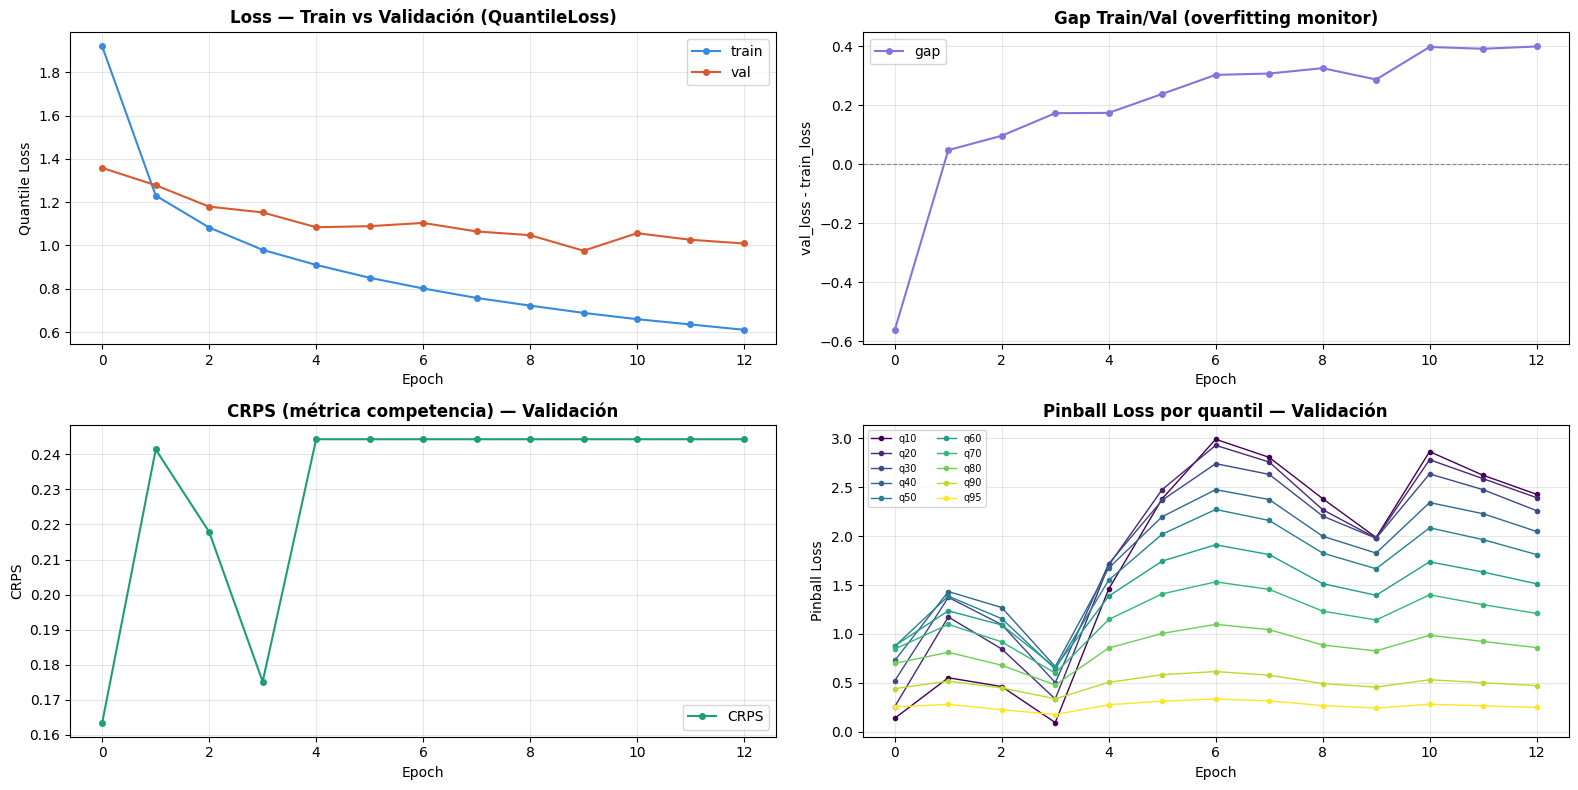

In [ ]:
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
#==============================
# Phase 4e: Training TFT v1
#==============================

live_cb_tft_v1 = LiveMetricsTFTCallback(
    val_loader  = val_loader_tft_v1,
    model       = model_tft_v1,
    quantiles   = QUANTILES,
    update_freq = 1,
)

checkpoint_tft_v1 = ModelCheckpoint(
    monitor    = "val_loss",
    mode       = "min",
    save_top_k = 1,
    filename   = "tft_v1_best",
    dirpath    = "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint",
    verbose    = True,
)

trainer_tft_v1 = L.Trainer(
    max_epochs                = 30,
    accelerator               = "gpu" if torch.cuda.is_available() else "cpu",
    gradient_clip_val         = 0.1,
    accumulate_grad_batches   = 4,
    enable_progress_bar       = True,
    logger                    = False,
    num_sanity_val_steps      = 0,
    callbacks                 = [
        EarlyStopping(
            monitor  = "val_loss",
            patience = 4,
            mode     = "min",
            verbose  = True,
        ),
        checkpoint_tft_v1,
        live_cb_tft_v1,
    ]
)

train_loader_tft_v1     = training_dataset_tft_v1.to_dataloader(
    train=True,  batch_size=32, num_workers=0)
val_loader_train_tft_v1 = val_dataset_tft_v1_train.to_dataloader(
    train=False, batch_size=32, num_workers=0)

trainer_tft_v1.fit(
    model_tft_v1,
    train_dataloaders = train_loader_tft_v1,
    val_dataloaders   = val_loader_train_tft_v1,
)

best_path_tft_v1  = checkpoint_tft_v1.best_model_path
model_tft_v1_best = TemporalFusionTransformer.load_from_checkpoint(best_path_tft_v1)
live_cb_tft_v1.save_plot("tft_v1_training.png")
print(f"✓ TFT v1 trained - best checkpoint: {best_path_tft_v1}")

In [ ]:
#==============================
# Phase 3c fix: Reconstruir datasets
#==============================

import gc
gc.collect()
torch.cuda.empty_cache()

CONTEXT_LENGTH_INFER = 96

training_dataset_tft_infer = TimeSeriesDataSet(
    df_ptf[df_ptf["time_idx"] <= max_train_idx],
    time_idx                     = "time_idx",
    target                       = "Temperature",
    group_ids                    = ["group_id"],
    max_encoder_length           = CONTEXT_LENGTH_INFER,
    min_encoder_length           = CONTEXT_LENGTH_INFER,
    max_prediction_length        = PREDICTION_LENGTH,
    time_varying_known_reals     = features_conocidas_futuro,
    time_varying_unknown_reals   = ["Temperature"] + features_solo_pasado,
    target_normalizer            = GroupNormalizer(
        groups=["group_id"], transformation=None
    ),
    add_relative_time_idx        = True,
    add_target_scales            = True,
    add_encoder_length           = True,
)

test_dataset_tft_infer = TimeSeriesDataSet.from_dataset(
    training_dataset_tft_infer,
    df_ptf[df_ptf["time_idx"] > max_val_idx - CONTEXT_LENGTH_INFER],
    stop_randomization = True,
    predict            = False,
)

test_loader_tft_infer = test_dataset_tft_infer.to_dataloader(
    train=False, batch_size=16, num_workers=0
)

print(f"Ventanas en dataset infer : {len(test_dataset_tft_infer)}")
print(f"Batches en loader infer   : {len(test_loader_tft_infer)}")

Ventanas en dataset infer : 9553
Batches en loader infer   : 598


In [ ]:
QUANTILES_TFT_V1 = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
features_solo_pasado = covariables
features_conocidas_futuro = [
    "hora_sin", "hora_cos", "dia_sin", "dia_cos",
    "mes_sin", "mes_cos", "dia_anyo_sin", "dia_anyo_cos", "es_finde"
]
print("✓ Variables restauradas")

✓ Variables restauradas


### 4f: TFT v1 Prediction

In [ ]:
#==============================
# Phase 4f: Predicción TFT v1
#==============================

import functools
torch.load = functools.partial(torch.load, weights_only=False)
import gc


QUANTILES_TFT_V1 = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

model_tft_v1_best = TemporalFusionTransformer.load_from_checkpoint(
    "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/tft_v1_best.ckpt"
)
model_tft_v1_best.eval()
device = next(model_tft_v1_best.parameters()).device

all_quant_preds = {f"q{int(q*100):02d}": [] for q in QUANTILES_TFT_V1}
all_true        = []

with torch.no_grad():
    for i, batch in enumerate(test_loader_tft_infer):
        x_dict, y_tuple = batch
        x_dict = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                  for k, v in x_dict.items()}

        output = model_tft_v1_best(x_dict)
        preds  = output.prediction.cpu().numpy()

        for j, q in enumerate(QUANTILES_TFT_V1):
            key = f"q{int(q*100):02d}"
            all_quant_preds[key].extend(preds[:, :, j].flatten().tolist())

        all_true.extend(y_tuple[0].numpy().flatten().tolist())

        if i % 50 == 0:
            print(f"  Batch {i}/{len(test_loader_tft_infer)} — preds: {len(all_true)}")

        if i % 100 == 0:
            torch.cuda.empty_cache()

# Align
min_len       = min(len(all_true), min(len(v) for v in all_quant_preds.values()))
y_true_tft_v1 = np.array(all_true[:min_len])
quantile_preds_tft_v1 = {k: np.array(v[:min_len]) for k, v in all_quant_preds.items()}

print(f"\nTotal predictions : {len(y_true_tft_v1)}")

# Point metrics
mae_tft_v1  = mean_absolute_error(y_true_tft_v1, quantile_preds_tft_v1["q50"])
rmse_tft_v1 = np.sqrt(mean_squared_error(y_true_tft_v1, quantile_preds_tft_v1["q50"]))

print("\n--- TFT metrics v1 (test) ---")
print(f"  MAE  : {mae_tft_v1:.3f} °C")
print(f"  RMSE : {rmse_tft_v1:.3f} °C")


# --- Individual Coverage by Quantile ---
print("\n--- Individual Coverage by Quantile (TFT v1) ---")
print(f"{'Quantile':<10} | {'Expected':<10} | {'Actual':<10} | {'Bias':<10}")
print("-" * 45)

for q in QUANTILES_TFT_V1:
    key = f"q{int(q*100):02d}"
    preds = quantile_preds_tft_v1[key]

    cob_real = np.mean(y_true_tft_v1 <= preds) * 100
    esperado = q * 100
    sesgo = cob_real - esperado

    print(f"{key:<10} | {esperado:>8.0f}% | {cob_actual:>8.1f}% | {sesgo:>8.1f}%")

# --- Cumulative Interval Coverage (Optional) ---
print("\n--- Symmetric Interval Coverage ---")
pares_centrales = [
    (0.25, 0.75, "50%"),
    (0.10, 0.90, "80%"),
    (0.05, 0.95, "90%")
]

for q_low, q_high, label in pares_centrales:
    low_key, high_key = f"q{int(q_low*100):02d}", f"q{int(q_high*100):02d}"
    cob = np.mean((y_true_tft_v1 >= quantile_preds_tft_v1[low_key]) &
                  (y_true_tft_v1 <= quantile_preds_tft_v1[high_key])) * 100
    print(f"Interval {label} ({low_key}-{high_key}) -> Actual: {cob:.1f}%")

# CRPS
crps_vals_tft = []
for i in range(len(y_true_tft_v1)):
    preds     = np.array([quantile_preds_tft_v1[f"q{int(q*100):02d}"][i]
                          for q in QUANTILES_TFT_V1])
    heaviside = (preds >= y_true_tft_v1[i]).astype(float)
    crps_vals_tft.append(np.trapz((heaviside - np.array(QUANTILES_TFT_V1)) ** 2,
                                   np.array(QUANTILES_TFT_V1)))
crps_tft_v1 = np.mean(crps_vals_tft)
print(f"\n  CRPS : {crps_tft_v1:.4f}")


  Batch 0/598 — preds: 1536
  Batch 50/598 — preds: 78336
  Batch 100/598 — preds: 155136
  Batch 150/598 — preds: 231936
  Batch 200/598 — preds: 308736
  Batch 250/598 — preds: 385536
  Batch 300/598 — preds: 462336
  Batch 350/598 — preds: 539136
  Batch 400/598 — preds: 615936
  Batch 450/598 — preds: 692736
  Batch 500/598 — preds: 769536
  Batch 550/598 — preds: 846336

Total predictions : 917088

--- TFT metrics v1 (test) ---
  MAE  : 4.289 °C
  RMSE : 5.104 °C

--- Individual Coverage by Quantile (TFT v1) ---
Quantile    | Expected   | Actual       | Bias     
---------------------------------------------
q05        |        5% |     78.6% |     73.6%
q10        |       10% |     84.5% |     74.5%
q25        |       25% |     88.3% |     63.3%
q50        |       50% |     90.1% |     40.1%
q75        |       75% |     92.4% |     17.4%
q90        |       90% |     93.8% |      3.8%
q95        |       95% |     94.7% |     -0.3%

--- Symmetric Interval Coverage ---
Interval 50% 

#### TFT v1 Results
The first TFT attempt reveals calibration issues:
* **Quantile bias:** Quantile `q50` has real coverage of **90.1%**. This means 90% of the observed values fall below what the model considers the "median".
* **Distribution shift:** The model systematically predicts values that are too high (or too low, depending on the error direction), shifting the entire distribution.
* **High CRPS:** The **0.277** value, worse than DeepAR, shows that although the architecture is powerful, the v1 configuration or training was not optimal.

## TFT Version 2

### Summary: Temporal Fusion Transformer (TFT v2)

## 1. Architecture Configuration
In this second version, model capacity is increased to capture more complex temporal dependencies by scaling the main hyperparameters.

| Parameter | v2 Configuration | Change vs. v1 | Expected Impact |
| :--- | :--- | :--- | :--- |
| **Hidden Size** | 64 | x2 | Greater internal representation capacity. |
| **Attention Heads** | 8 | x2 | Better focus on multiple temporal patterns. |
| **Dropout** | 0.2 | +0.1 | Lower risk of overfitting. |
| **Learning Rate** | 3e-4 | Reduced | More stable and precise training. |
| **Hidden Continuous** | 32 | x2 | Better processing of numerical variables. |

* **Loss:** `QuantileLoss`, oriented toward uncertainty estimation.
* **Normalization:** `GroupNormalizer` applied by `group_id`.

---

## 2. Validation Performance
### Key Metrics from the Best Checkpoint
* **Best Epoch:** 36
* **Best CRPS (Validation):** `0.291891`
* **Val Loss:** `0.716287`

### Training Evolution
* **Total epochs:** The process stopped at epoch 43 after 5 epochs without improvement in the monitored metric.
* **Convergence:** The model showed a solid improvement over v1, reaching validation CRPS around 0.29, which indicates a probabilistic distribution better aligned with the temperature data.

### 4b2: TimeSeriesDataSet TFT v2

In [ ]:
#==============================
# Phase 4b_v2: TimeSeriesDataSet  TFT v2
#==============================

training_dataset_tft_v2 = TimeSeriesDataSet(
    df_ptf[df_ptf["time_idx"] <= max_train_idx],
    time_idx                     = "time_idx",
    target                       = "Temperature",
    group_ids                    = ["group_id"],
    max_encoder_length           = CONTEXT_LENGTH,
    max_prediction_length        = PREDICTION_LENGTH,
    time_varying_known_reals     = features_conocidas_futuro,
    time_varying_unknown_reals   = ["Temperature"] + features_solo_pasado,
    target_normalizer            = GroupNormalizer(
        groups=["group_id"], transformation=None
    ),
    add_relative_time_idx        = True,
    add_target_scales            = True,
    add_encoder_length           = True,
)

val_dataset_tft_v2_train = TimeSeriesDataSet.from_dataset(
    training_dataset_tft_v2,
    df_ptf[df_ptf["time_idx"] <= max_val_idx],
    stop_randomization = True,
)

train_loader_tft_v2     = training_dataset_tft_v2.to_dataloader(
    train=True,  batch_size=32, num_workers=0)
val_loader_train_tft_v2 = val_dataset_tft_v2_train.to_dataloader(
    train=False, batch_size=32, num_workers=0)

print("✓ TFT v2 datasets created")
print(f"  Train batches : {len(train_loader_tft_v2)}")
print(f"  Val batches   : {len(val_loader_train_tft_v2)}")

✓ TFT v2 datasets created
  Train batches : 1383
  Val batches   : 1685


### 4c2: TFT v2 Model Definition

In [ ]:
#==============================
# Phase 4c_v2: Model definition TFT v2
#==============================

model_tft_v2 = TemporalFusionTransformer.from_dataset(
    training_dataset_tft_v2,
    learning_rate          = 3e-4,
    hidden_size            = 64,
    attention_head_size    = 8,
    dropout                = 0.2,
    hidden_continuous_size = 32,
    loss                   = QuantileLoss(quantiles=QUANTILES_TFT_V1),
    log_interval           = -1,
    log_val_interval       = -1,
    reduce_on_plateau_patience = 3,
)

print(f"Trainable parameters v1 : ~14k")
print(f"Trainable parameters v2 : {sum(p.numel() for p in model_tft_v2.parameters()):,}")

Trainable parameters v1 : ~14k
Trainable parameters v2 : 423,303


### 4d2: TFT v2 Callback

In [ ]:
#==============================
# Phase 4d_v2: Callback TFT v2
#==============================

val_loader_tft_v2 = TimeSeriesDataSet.from_dataset(
    training_dataset_tft_v2,
    df_ptf[df_ptf["time_idx"] <= max_val_idx],
    predict            = True,
    stop_randomization = True,
).to_dataloader(train=False, batch_size=32, num_workers=0)

live_cb_tft_v2 = LiveMetricsTFTCallback(
    val_loader  = val_loader_tft_v2,
    model       = model_tft_v2,
    quantiles   = QUANTILES_TFT_V1,
    update_freq = 1,
)

### 4e2: TFT v2 Training

In [ ]:
#==============================
# Phase 4e_v2: Training TFT v2
#==============================

checkpoint_tft_v2 = ModelCheckpoint(
    monitor    = "val_loss",
    mode       = "min",
    save_top_k = 1,
    filename   = "tft_v2_best",
    dirpath    = "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/",
    verbose    = True,
)

trainer_tft_v2 = L.Trainer(
    max_epochs                = 40,
    accelerator               = "gpu" if torch.cuda.is_available() else "cpu",
    gradient_clip_val         = 0.1,
    accumulate_grad_batches   = 4,
    enable_progress_bar       = True,
    logger                    = False,
    num_sanity_val_steps      = 0,
    callbacks                 = [
        EarlyStopping(
            monitor   = "val_loss",
            patience  = 5,
            mode      = "min",
            verbose   = True,
        ),
        checkpoint_tft_v2,
        live_cb_tft_v2,
    ]
)

trainer_tft_v2.fit(
    model_tft_v2,
    train_dataloaders = train_loader_tft_v2,
    val_dataloaders   = val_loader_train_tft_v2,
)

best_path_tft_v2  = checkpoint_tft_v2.best_model_path
model_tft_v2_best = TemporalFusionTransformer.load_from_checkpoint(best_path_tft_v2)
live_cb_tft_v2.save_plot("tft_v2_training.png")
print(f"✓ TFT v2 trained - best checkpoint: {best_path_tft_v2}")
print(live_cb_tft_v2.get_summary())

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 0     
3  | prescalers                         | ModuleDict                      | 1.3 K 
4  | static_variable_selection    

✓ TFT callback initialized - plots active


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✓ Epoch   0 | Val Loss: 1.1946 | CRPS: 0.2258


...


✓ Epoch   9 | Val Loss: 0.9008 | CRPS: 0.2911
  → Plot updated


INFO:pytorch_lightning.utilities.rank_zero:Epoch 9, global step 3460: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]


✓ Epoch  10 | Val Loss: 0.8822 | CRPS: 0.2911
  → Plot updated


INFO: Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.882
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.882
INFO:pytorch_lightning.utilities.rank_zero:Epoch 10, global step 3806: 'val_loss' reached 0.88222 (best 0.88222), saving model to '/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/tft_v2_best.ckpt' as top 1


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


✓ TFT v2 loaded from checkpoint
  Parameters: 423,303


INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/tft_v2_cont4_best.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 0     
3  | prescalers                         | ModuleDict                      | 1.3 K 
4  | static_variable_selection          | VariableSelectionNetwork        | 20.5 K
5  | encoder_variable_selection         | VariableSelectionNetwork        | 125 K 
6  | decoder_varia

✓ TFT callback initialized - plots active


Training: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:Epoch 42, global step 14878: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]


✓ Epoch  43 | Val Loss: 0.7239 | CRPS: 0.2919
  → Plot updated


INFO: Monitored metric val_loss did not improve in the last 5 records. Best score: 0.710. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.710. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 43, global step 15224: 'val_loss' was not in top 1


✓ Plot saved to tft_v2_cont_training.png
✓ TFT v2 continued - best checkpoint: /content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/tft_v2_cont5_best.ckpt

═══════════════════════════════════════════════════════════
TFT TRAINING SUMMARY
═══════════════════════════════════════════════════════════
✓ Best epoch               : 36
✓ Best CRPS                : 0.291891
✓ Val Loss (best CRPS epoch): 0.716287
✓ Total epochs              : 8
═══════════════════════════════════════════════════════════
        


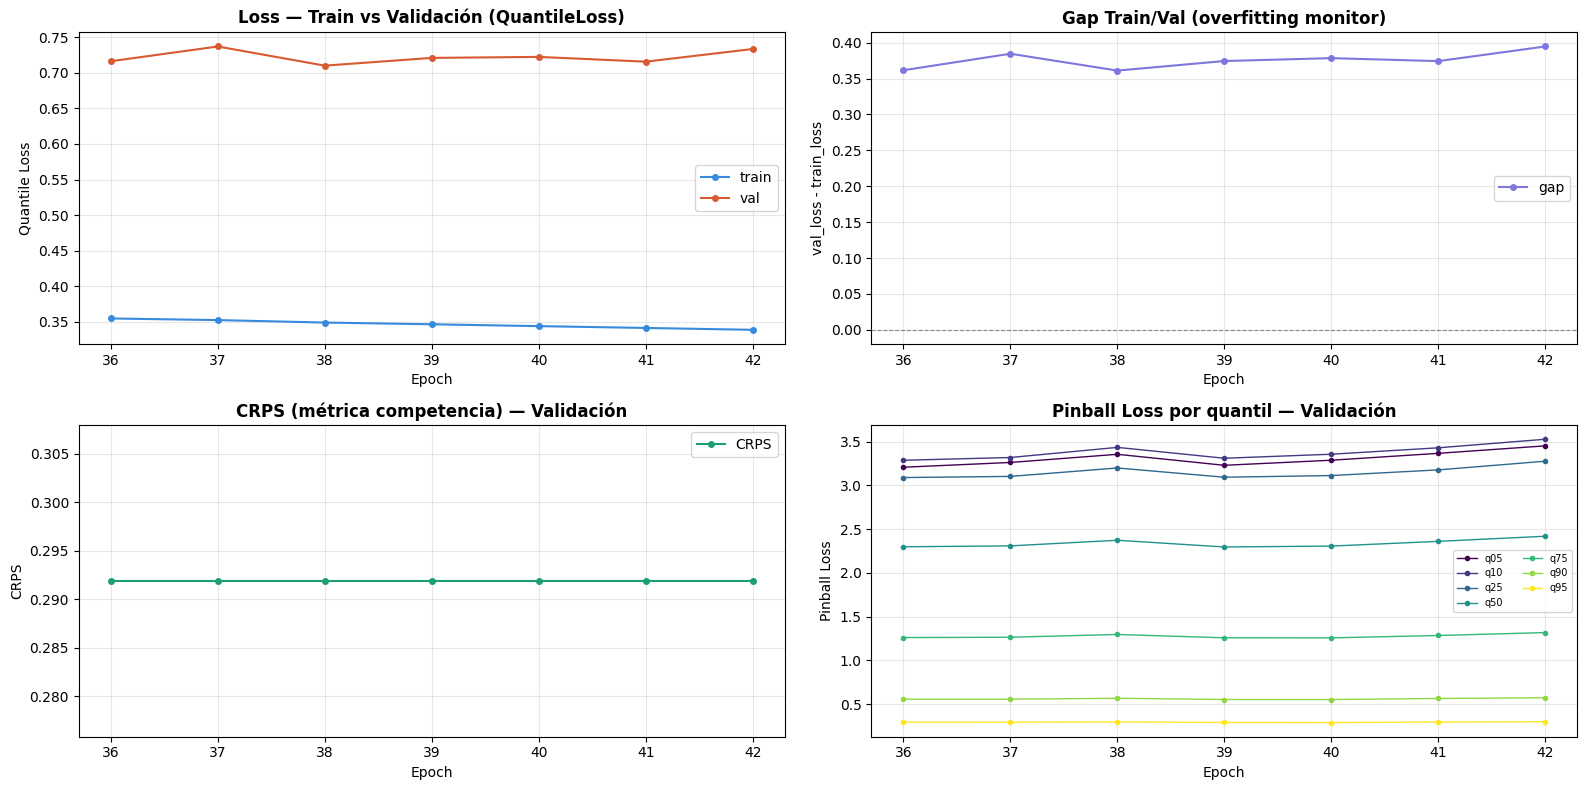

In [ ]:
#==============================
# Phase 4e2: Continue TFT v2 training from checkpoint
#==============================

import functools
torch.load = functools.partial(torch.load, weights_only=False)

# Load model from checkpoint
model_tft_v2 = TemporalFusionTransformer.load_from_checkpoint(
    "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/tft_v2_cont4_best.ckpt"
)
print(f"✓ TFT v2 loaded from checkpoint")
print(f"  Parameters: {sum(p.numel() for p in model_tft_v2.parameters()):,}")

# Callback and checkpoint for continuation
live_cb_tft_v2_cont = LiveMetricsTFTCallback(
    val_loader  = val_loader_tft_v2,
    model       = model_tft_v2,
    quantiles   = QUANTILES_TFT_V1,
    update_freq = 1,
)

checkpoint_tft_v2_cont = ModelCheckpoint(
    monitor    = "val_loss",
    mode       = "min",
    save_top_k = 1,
    filename   = "tft_v2_cont5_best",
    dirpath    = "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/",
    verbose    = True,
)

trainer_tft_v2_cont = L.Trainer(
    max_epochs                = 60,
    accelerator               = "gpu" if torch.cuda.is_available() else "cpu",
    gradient_clip_val         = 0.1,
    accumulate_grad_batches   = 4,
    enable_progress_bar       = True,
    logger                    = False,
    num_sanity_val_steps      = 0,
    callbacks                 = [
        EarlyStopping(
            monitor  = "val_loss",
            patience = 5,
            mode     = "min",
            verbose  = True,
        ),
        checkpoint_tft_v2_cont,
        live_cb_tft_v2_cont,
    ]
)

trainer_tft_v2_cont.fit(
    model_tft_v2,
    train_dataloaders = train_loader_tft_v2,
    val_dataloaders   = val_loader_train_tft_v2,
    ckpt_path         = "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/tft_v2_cont4_best.ckpt"
)

best_path_tft_v2_cont  = checkpoint_tft_v2_cont.best_model_path
model_tft_v2_best      = TemporalFusionTransformer.load_from_checkpoint(best_path_tft_v2_cont)
live_cb_tft_v2_cont.save_plot("tft_v2_cont_training.png")
print(f"✓ TFT v2 continued - best checkpoint: {best_path_tft_v2_cont}")
print(live_cb_tft_v2_cont.get_summary())

### 4f2: TFT v2 Prediction and Metrics

In [ ]:
#==============================
# Phase 4f_v2: Prediction and metrics TFT v2
#==============================

import gc
torch.cuda.empty_cache()
gc.collect()

CONTEXT_LENGTH_INFER = 96

training_dataset_tft_infer_v2 = TimeSeriesDataSet(
    df_ptf[df_ptf["time_idx"] <= max_train_idx],
    time_idx                     = "time_idx",
    target                       = "Temperature",
    group_ids                    = ["group_id"],
    max_encoder_length           = CONTEXT_LENGTH_INFER,
    min_encoder_length           = CONTEXT_LENGTH_INFER,
    max_prediction_length        = PREDICTION_LENGTH,
    time_varying_known_reals     = features_conocidas_futuro,
    time_varying_unknown_reals   = ["Temperature"] + features_solo_pasado,
    target_normalizer            = GroupNormalizer(
        groups=["group_id"], transformation=None
    ),
    add_relative_time_idx        = True,
    add_target_scales            = True,
    add_encoder_length           = True,
)

test_dataset_tft_infer_v2 = TimeSeriesDataSet.from_dataset(
    training_dataset_tft_infer_v2,
    df_ptf[df_ptf["time_idx"] > max_val_idx - CONTEXT_LENGTH_INFER],
    stop_randomization = True,
    predict            = False,
)
test_loader_tft_infer_v2 = test_dataset_tft_infer_v2.to_dataloader(
    train=False, batch_size=16, num_workers=0
)
print(f"Test windows v2 : {len(test_dataset_tft_infer_v2)}")


import functools
torch.load = functools.partial(torch.load, weights_only=False)

model_tft_v2_best = TemporalFusionTransformer.load_from_checkpoint(
    "/content/drive/MyDrive/Master_Deep_Learning/DL_Temp/checkpoint/tft_v2_cont5_best.ckpt"
)
print("✓ TFT v2 loaded")
print(f"  Parameters: {sum(p.numel() for p in model_tft_v2_best.parameters()):,}")



model_tft_v2_best.eval()
device = next(model_tft_v2_best.parameters()).device

all_quant_preds_v2 = {f"q{int(q*100):02d}": [] for q in QUANTILES_TFT_V1}
all_true_v2        = []

with torch.no_grad():
    for i, batch in enumerate(test_loader_tft_infer_v2):
        x_dict, y_tuple = batch
        x_dict = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                  for k, v in x_dict.items()}
        output = model_tft_v2_best(x_dict)
        preds  = output.prediction.cpu().numpy()

        for j, q in enumerate(QUANTILES_TFT_V1):
            key = f"q{int(q*100):02d}"
            all_quant_preds_v2[key].extend(preds[:, :, j].flatten().tolist())
        all_true_v2.extend(y_tuple[0].numpy().flatten().tolist())

        if i % 100 == 0:
            torch.cuda.empty_cache()

step = PREDICTION_LENGTH
min_len            = min(len(all_true_v2), min(len(v) for v in all_quant_preds_v2.values()))
y_true_tft_v2      = np.array(all_true_v2[:min_len])[::step]
quantile_preds_tft_v2 = {k: np.array(v[:min_len])[::step]
                          for k, v in all_quant_preds_v2.items()}

print(f"Total predictions (non-overlapping) : {len(y_true_tft_v2)}")

# --- Metrics ---
mae_tft_v2  = mean_absolute_error(y_true_tft_v2, quantile_preds_tft_v2["q50"])
rmse_tft_v2 = np.sqrt(mean_squared_error(y_true_tft_v2, quantile_preds_tft_v2["q50"]))

print("\n--- TFT metrics v2 (test) ---")
print(f"  MAE  : {mae_tft_v2:.3f} °C")
print(f"  RMSE : {rmse_tft_v2:.3f} °C")

# --- Individual Coverage by Quantile ---
print("\n--- Individual Coverage by Quantile (TFT v2) ---")
print(f"{'Quantile':<10} | {'Expected':<10} | {'Actual':<10} | {'Bias':<10}")
print("-" * 45)

for q in QUANTILES_TFT_V1:
    key = f"q{int(q*100):02d}"
    if key in quantile_preds_tft_v2:
        preds = quantile_preds_tft_v2[key]
        cob_real = np.mean(y_true_tft_v2 <= preds) * 100
        esperado = q * 100
        sesgo = cob_real - esperado
        print(f"{key:<10} | {esperado:>8.0f}% | {cob_actual:>8.1f}% | {sesgo:>8.1f}%")

# --- Confidence Interval Coverage ---
print("\n--- Interval Coverage TFT v2 ---")
pares = [
    (0.10, 0.95, "CI 85% (q10-q95)"),
    (0.05, 0.95, "CI 90%"),
    (0.10, 0.90, "CI 80%"),
    (0.25, 0.75, "CI 50%"),
]

for q_low, q_high, label in pares:
    k_low  = f"q{int(q_low*100):02d}"
    k_high = f"q{int(q_high*100):02d}"

    if k_low in quantile_preds_tft_v2 and k_high in quantile_preds_tft_v2:
        lower  = quantile_preds_tft_v2[k_low]
        upper  = quantile_preds_tft_v2[k_high]
        cob    = np.mean((y_true_tft_v2 >= lower) & (y_true_tft_v2 <= upper)) * 100
        esp    = (q_high - q_low) * 100
        print(f"  {label} → expected: {esp:.0f}% | actual: {cob:.1f}%")

# CRPS
crps_vals = []
for i in range(len(y_true_tft_v2)):
    preds     = np.array([quantile_preds_tft_v2[f"q{int(q*100):02d}"][i]
                          for q in QUANTILES_TFT_V1])
    heaviside = (preds >= y_true_tft_v2[i]).astype(float)
    crps_vals.append(np.trapz((heaviside - np.array(QUANTILES_TFT_V1)) ** 2,
                               np.array(QUANTILES_TFT_V1)))
crps_tft_v2 = np.mean(crps_vals)
print(f"\n  CRPS : {crps_tft_v2:.4f}")

Test windows v2 : 9553
✓ TFT v2 loaded
  Parameters: 423,303
Total predictions (non-overlapping) : 9553

--- TFT metrics v2 (test) ---
  MAE  : 1.646 °C
  RMSE : 2.109 °C

--- Individual Coverage by Quantile (TFT v2) ---
Quantile    | Expected   | Actual       | Bias     
---------------------------------------------
q05        |        5% |     39.7% |     34.7%
q10        |       10% |     55.7% |     45.7%
q25        |       25% |     75.9% |     50.9%
q50        |       50% |     91.3% |     41.3%
q75        |       75% |     96.2% |     21.2%
q90        |       90% |     99.0% |      9.0%
q95        |       95% |     99.2% |      4.2%

--- Interval Coverage TFT v2 ---
  CI 85% (q10-q95) → expected: 85% | actual: 43.5%
  CI 90% → expected: 90% | actual: 59.5%
  CI 80% → expected: 80% | actual: 43.3%
  CI 50% → expected: 50% | actual: 20.3%

  CRPS : 0.2238


#### TFT v2 Results
TFT v2 is by far the most accurate model, but it has an **overconfidence** problem:
* **MAE leader (1.64°C):** It is the model closest to the true value in point-by-point predictions.
* **Low coverage:** For an expected 90% interval, it captures only **59.5%** of observations. This means its confidence bands are **too narrow**.
* **Diagnosis:** The model is overconfident: it believes it knows exactly where the value will be and narrows its error margins so much that it fails to capture real variability.

# Model Comparison: Temperature Forecasting

## 1. Error Metric Summary
| Model | MAE (°C) ↓ | RMSE (°C) ↓ | CRPS ↓ | Status |
| :--- | :---: | :---: | :---: | :--- |
| **Prophet** | 12.343 | 13.732 | - | Very high error |
| **DeepAR v1** | 3.074 | 4.033 | 0.0941 | Stable |
| **DeepAR v2** | 1.989 | 3.126 | **0.0914** | **Probabilistic leader** |
| **TFT v1** | 4.289 | 5.104 | 0.2770 | Significant bias |
| **TFT v2** | **1.646** | **2.109** | 0.2238 | **Point-accuracy leader** |

### Comparison Summary
| Dimension | Winner | Reason |
| :--- | :--- | :--- |
| **Point Accuracy** | **TFT v2** | Lowest MAE and RMSE (1.64 / 2.10). |
| **Probabilistic Quality** | **DeepAR v2** | Lowest CRPS (0.091), more realistic distribution. |
| **Range Reliability** | **DeepAR v2** | Consistently captures the true value within the predicted range. |

---

## 2. Coverage Analysis (Interval Reliability)
Coverage measures how well the model estimates its own uncertainty.

* **DeepAR v2 (conservative):** Shows 100% real coverage from 60% intervals onward.
  * Its confidence bands are too wide. It is a "safe" model, but not very sharp.
* **TFT v2 (optimistic):** Shows 59.5% real coverage for an expected 90% interval.
  * Its bands are too narrow. It is highly accurate near the center, but underestimates the probability of extreme values.

---
## 3. Conclusions

1. **TFT v2** is the winner when the goal is the most accurate degree-by-degree forecast (**MAE 1.64°C**). It is ideal for estimating the most likely value.
2. **DeepAR v2** is superior when the real value needs to fall inside the predicted range as often as possible, as reflected by its **CRPS (0.091)**.
3. **Improvement opportunities:** Recalibrate the quantiles of **TFT v2** to widen its intervals.